# Stratégie « Calendar-Time Disclosure » — achats divulgués, value-weighted, fenêtre courte

**Pré-enregistrement gelé le 2026-07-10, avant toute exécution de backtest.**
Tout ce qui suit (§0) fixe la stratégie, la grille de tests et les critères de décision.
Aucune cellule de calcul de rendement de stratégie ne précède ce cadre.

## §0. Pourquoi ce test — et pourquoi il n'a pas déjà été fait ici

- Les notebooks 03/04/05b/06 ont fermé la copie **par membre** (top-K Sharpe walk-forward, max $t=1{,}30$ ;
  compte réel $+1{,}95\,\%$/an, $t=0{,}76$, Sharpe $0{,}74 <$ SPY $0{,}82$) et le drift **équi-pondéré par trade**
  ($+7$ bps à 1 mois, écrasé par $2c = 40$ bps d'aller-retour **par événement**).
- La littérature qui survit fait **autre chose** : un portefeuille **calendar-time value-weighted d'achats
  divulgués**, rebalancé mensuellement (Pyun 2025 — alpha factoriel positif, plus fort large caps / House /
  post-2020 ; Lazzaretto 2024 — $>90$ bps le mois post-publication, temporaire ; Chen-Sacerdote 2026 — la
  *seule* spécification positive est value-weighted).
- **La correction méthodologique centrale** : en calendar-time, les coûts se paient sur le **turnover du
  portefeuille**, pas par trade. Si $\rho$ est la fraction de poids réellement renouvelée à chaque cycle de
  $W$ jours :
$$\alpha^{net}_{ann} > 0 \iff \mathbb{E}[\mathrm{CAAR}_W] > 2\,c\,\rho
\qquad (= 40 \text{ bps si } \rho = 1,\ \ 20 \text{ bps si } \rho = 0{,}5, \text{ à } c = 20 \text{ bps})$$
  Les mégacaps rachetées en continu donnent $\rho \ll 1$ : le « non » du 06 ne préjugeait pas de ce test.
- **Re-lecture du $+7$ bps ($t=1{,}9$) du 06** : ce $t$ supposait $58\,910$ événements indépendants. Ils
  partagent le mois (~390 achats/mois) et les mêmes titres : avec une corrélation intra-mois $\rho_c \approx 0{,}05$,
  l'inflation de Moulton $\sqrt{1+(\bar m - 1)\rho_c} \approx 4{,}5$ ramène ce $t$ à $\approx 0{,}4$.
  Le portefeuille calendar-time **est** la correction (un mois = une observation ; Fama 1998).

## §0.1 Primitives et règle point-in-time

Trade déclaré $k$ : $(m_k,\ i_k,\ t_k^{tr},\ t_k^{disc},\ d_k,\ A_k,\ s_k^{GICS},\ \mathcal{C}(m_k))$ —
membre, ticker, date de transaction, date de publication, sens ($d_k=+1$ achat, $-1$ vente),
montant midpoint de la tranche STOCK Act, secteur GICS, comités du membre.

- **Règle J+1 (identique au 06)** : une publication le jour $s$ est exécutable au plus tôt au close de
  $i_{exec}(k) = \texttt{CAL.searchsorted}(t_k^{disc},\ \texttt{right})$, le premier jour de bourse
  **strictement après** $s$.
- **Jamais** d'entrée à $t_k^{tr}$ : seule la date de publication est jouable.
- **Déduplication gelée** : `natural_key_hash` en double = re-dépôt identique du même trade
  → `drop_duplicates(natural_key_hash, keep="first")` (6 407 lignes). Les doublons multi-comptes
  (même trade déclaré self + conjoint avec hash distinct) sont **conservés** dans la spec primaire ;
  la variante `owner=self` est un diagnostic hors protocole.

## §0.2 Univers, signal, poids

**Univers au rebalancement $t$** (indice de `CAL`) :
$$\mathcal{U}_t = \Big\{ i :\ \texttt{asset\_class}=\text{stock},\ \ \#\{u \le t : P_{i,u}\ \text{observé}\} \ge 126,\ \
\text{dernier prix observé} \ge t-4,\ \ \mathrm{ADV}^{63}_{i,t} \ge 5\ \text{M\$/j} \Big\}$$
$$\mathrm{ADV}^{63}_{i,t} = \operatorname{med}_{u \in (t-63,\ t]}\big(P^{raw}_{i,u} \cdot V_{i,u}\big)
\qquad \text{(close \emph{brut} yfinance} \times \text{volume : le vrai dollar-volume, insensible aux splits)}$$

**Flux sur la fenêtre** $W \in \{21, 63\}$ jours de bourse — trades éligibles :
$\mathcal{K}_{i,t}(W) = \{k : i_k = i,\ t - W < i_{exec}(k) \le t\}$ :
$$\mathrm{Buy}_{i,t} = \sum_{k \in \mathcal{K}_{i,t}} A_k\,\mathbf{1}_{d_k=+1},\qquad
\mathrm{Sell}_{i,t} = \sum_{k \in \mathcal{K}_{i,t}} A_k\,\mathbf{1}_{d_k=-1},\qquad
\mathrm{NetBuy}_{i,t} = \big[\mathrm{Buy}_{i,t} - \mathrm{Sell}_{i,t}\big]^{+}$$

**Composition** : $\mathcal{P}_t = \{i \in \mathcal{U}_t : \mathrm{NetBuy}_{i,t} > 0\}$ (~100–200 noms attendus,
pas de top-$N$ : le cap remplace la concentration).

**Poids** ($w_{max} = 10\,\%$, renormalisation **itérative** — une seule passe peut repousser d'autres poids
au-dessus du cap ; si le cap est infaisable, $|\mathcal{P}_t| \cdot w_{max} < 1$, chaque nom reçoit $w_{max}$
et le solde reste en **cash** à rendement nul) :
$$\text{LW (primaire, value-weighted à la Pyun)} : \tilde w_{i,t} \propto \mathrm{ADV}^{63}_{i,t}
\qquad\qquad \text{SW (variante NANC-like)} : \tilde w_{i,t} \propto \log\big(1 + \mathrm{NetBuy}_{i,t}\big)$$

**Révision de la couche « Quality » de la note maths** (zéro paramètre libre — chaque terme sourcé) :

| Terme de la note | Sort | Raison |
|---|---|---|
| Rec (récurrence) | absorbé | $\sum_k$ dans le flux encode déjà la récurrence |
| MB (multiple buyers) | **supprimé** | Herron 2026 : le co-achat **dégrade** la performance |
| LT (large trade) | **supprimé** | Belmont JPE 2022 : les achats $>250$ k\$ sont **pires** ; $\log(1+A)$ amortit déjà |
| RS (recent sales) | absorbé | le netting $[\mathrm{Buy}-\mathrm{Sell}]^+$ fait ce travail sans paramètre |
| OO (one-off) | supprimé | pénaliser l'acheteur isolé = l'inverse de Herron ; non sourcé |
| Lob/PAC/Gov/Bill | hors périmètre | données absentes du repo (assumé, cf. §0.7) |
| **Ajout : Spec** | filtre variant | Lazzaretto 2024 : sous-échantillon spéculatif $+9$ bps/j |
| **Ajout : CI** | filtre variant | Abdurakhmonov 2023 : effet $\times 5$ si juridiction de comité sur l'industrie |

**Filtres pré-enregistrés** (appliqués aux trades des deux sens, puis netting) :
$$\mathrm{Spec}_{m,i,t} = \mathbf{1}\big\{\exists\ k, k' : m_k = m_{k'} = m,\ i_k = i_{k'} = i,\ d_k = +1,\ d_{k'} = -1,\
i_{exec} \in (t - 252,\ t]\big\}$$
$$\mathrm{CI}_k = \mathbf{1}\big\{\exists\ c \in \mathcal{C}(m_k) : \mathrm{GICS}(i_k) \in \mathcal{J}(c)\big\}
\qquad \mathcal{J} = \text{matrice comité} \to \text{secteurs, gelée au §0.5}$$

## §0.3 Portefeuille, coûts, évaluation

**Rebalancement mensuel** au dernier jour de bourse du mois. Premier : 2026-06-30 → non, **2014-06-30**
(burn-in commun : couvre $W=63$ et l'ADV 63 j pour toutes les configurations) ; dernier : **2026-04-30** ;
évaluation arrêtée au **2026-05-29** (fin des facteurs K. French ; le lag médian de 27 j tronque de toute
façon les publications de juin).

Entre deux rebalancements les poids driftent ; au rebalancement, le turnover compte **les deux jambes**
(convention du moteur du 06) :
$$w^{drift}_{i,t+1} = \frac{w_{i,t}(1 + r_{i,t+1})}{1 + \sum_j w_{j,t} r_{j,t+1}},\qquad
r^p_{t+1} = \sum_i w_{i,t}\, r_{i,t+1},\qquad
\mathrm{TO}_t = \sum_i \big|w^{cible}_{i,t} - w^{drift}_{i,t}\big|$$
$$r^{p,net}_t = (1 + r^p_t)(1 - c\,\mathrm{TO}_t) - 1,\qquad
\mathrm{NAV}_T = \prod_{t \le T}(1 + r^{p,net}_t)$$

**Coûts** : le critère de décision est à $c = 10$ bps/jambe (large caps filtrées ADV $\ge 5$ M\$/j ;
spread + impact réalistes) ; $c = 20$ bps (convention du repo) et $40$ bps affichés en stress.

**Évaluation** (rendements quotidiens nets) — modèle primaire Carhart 4 (les facteurs sur disque),
FF5+MOM en robustesse :
$$r^{p,net}_t - r^f_t = \alpha + \beta_M\,\mathrm{MKT}_t + \beta_S\,\mathrm{SMB}_t + \beta_H\,\mathrm{HML}_t
+ \beta_U\,\mathrm{MOM}_t + \varepsilon_t, \qquad \alpha_{ann} = 252\,\hat\alpha$$
- **Newey-West** $L = 21$ en quotidien (≥ règle d'Andrews $0{,}75\,T^{1/3} \approx 11$ pour $T \approx 3\,000$ ;
  = un cycle de détention) ; $L = 6$ pour la table mensuelle. Oracle : `statsmodels` HAC.
- **≥ 2 benchmarks** (Hanousek 2023 : « le benchmark crée l'alpha ») : SPY **et** un
  **composite sectoriel auto-répliquant** $r^{sect}_{t+1} = \sum_s \omega_{s,t}\, r^{XL_s}_{t+1}$ avec
  $\omega_{s,t} = \sum_{i \in s} w_{i,t}$ — même mix sectoriel jour par jour : l'excès survivant est de la
  **sélection intra-secteur**, pas du tilt. QQQ affiché (ombre de style mega-cap tech), non décisionnel.
- Conventions du repo pour comparabilité : `stats_ptf` (CAGR, vol, Sharpe, maxDD), IR, `IR_annuel`
  (excès annuels composés), appraisal.

## §0.4 La grille FERMÉE ($N = 12$), la multiplicité, les gates

$$\underbrace{W \in \{21, 63\}}_{2} \times \underbrace{\{\mathrm{LW}, \mathrm{SW}\}}_{2}
\times \underbrace{\{\text{tous},\ \mathrm{Spec},\ \mathrm{CI}\}}_{3} = \mathbf{12\ tests}
\qquad \text{Primaire unique : } (W{=}21,\ \mathrm{LW},\ \text{tous})$$

Un test $=$ un $t_{NW}(\hat\alpha^{net}_{C4})$ sur la période complète. Sous $H_0$ (approximation de Gumbel,
même formule que le 05b) :
$$\mathbb{E}\big[\max_{n \le 12} t_n \,\big|\, H_0\big] \approx (1-\gamma)\,\Phi^{-1}\big(1 - \tfrac{1}{12}\big)
+ \gamma\,\Phi^{-1}\big(1 - \tfrac{1}{12e}\big) \approx \mathbf{1{,}66}, \qquad \mathrm{SD} \approx 0{,}63$$
Un max-$t$ de $\sim 1{,}7$ sur la grille = ce que le bruit produit. Les 12 cellules étant corrélées
positivement, 1,66 est conservateur (validation Monte-Carlo au §6).

**Gates (séquentiels, tous chiffrés ici, avant tout run)** :

| Gate | Critère | Si échec |
|---|---|---|
| **G0 données** | (a) preuve adjusted-close : $r^{SPY,cache} \sim \mathrm{MKT} + r^f$ avec $|\beta - 1| \le 0{,}02$, $|\alpha_{ann}| \le 0{,}5\,\%$, $R^2 \ge 0{,}98$ ; (b) ADV calculable $\ge 95\,\%$ du flux d'achat en \$ ; couverture prix $\ge 85\,\%$ du flux | STOP — réparer les données |
| **G1 event-study** | descriptif, **pas un stop** : CAAR 21 j en cohortes mensuelles (Jaffe-Mandelker), pondération ADV intra-cohorte, double benchmark ; chiffre le break-even $2c\rho$ | — |
| **G2 primaire S0** | **GO ssi** $t_{NW} \ge 2{,}0$ **et** $\alpha^{net}_{ann} \ge 150$ bps à $c{=}10$ **et** signe $\hat\alpha > 0$ sur 2014-19 **et** 2020-26 **et** excès net vs composite sectoriel $> 0$ avec IR $\ge 0{,}3$ | no-go (voir règle) |
| **G3 grille** | secondaires revendicables à $t \ge 3{,}0$ seulement ; reporter $\max t$ vs $1{,}66$ + DSR | — |
| **G4 placebos** | P1 (dates $+U\{63..252\}$ j) et P2 (tickers permutés intra GICS×mois×tercile ADV), $B = 1000$, $p < 0{,}05$ chacun ; ventes $\approx 0$ ; drop-one-member top-10 | verdict rétrogradé |

**Règle de décision** :
- $t \in\ ]2 ; 3]$ sur S0 = « **réplication confirmatoire** » (pré-enregistrée, dérivée de la littérature — on
  dit honnêtement que le choix du design est *en partie* informé par le $+7$ bps vu au 06).
- $t > 3$ = « **découverte** » (tient compte des ~160 essais historiques du projet, $\mathbb{E}[\max t] \approx 2{,}7$).
- **Zone grise $t \in [1{,}3 ; 2[$ = no-go ferme.** Aucune re-spécification sur les mêmes données.
  Seule extension autorisée : données **nouvelles** (mois futurs, champ options S1/S2).
- 150 bps ≈ frais NANC (72 bps) + marge tax-drag/slippage non modélisés : en dessous, économiquement mort
  même si statistiquement vivant.
- **Procédure aveugle** : $\hat\sigma_\varepsilon$ et $N_{eff}$ mensuels sont calculés et regardés **avant**
  $\hat\alpha$ (§5). Seul degré de liberté conditionnel : si $\hat\sigma_\varepsilon > 2{,}5\,\%$/mois,
  resserrer $w_{max}$ à $5\,\%$ est permis (décision sur une statistique indépendante de $\alpha$).

## §0.5 Matrice comité → secteurs GICS $\mathcal{J}$ (gelée ici, justifiée par le champ `jurisdiction` officiel)

Codes racine THOMAS présents dans la table (31). Mappés (19) — chaque ligne cite la juridiction :

| Code | Comité | Secteurs GICS | Justification (extrait `jurisdiction`) |
|---|---|---|---|
| HSAG / SSAF | Agriculture (H/S) | Consumer Staples, Materials | « agriculture, food, rural development, forestry » |
| HSAS / SSAS | Armed Services (H/S) | Industrials | « military and defense » |
| HLIG | Intelligence (House) | Industrials | « oversight of the Intelligence Community … Military Intelligence Program » |
| HSHM | Homeland Security | Industrials, Information Technology | « border and maritime security ; cybersecurity and infrastructure protection ; transportation security » |
| HSBA | Financial Services | Financials, Real Estate | « banking system, housing, insurance, securities and exchanges » |
| SSBK | Banking, Housing, Urban Affairs | Financials, Real Estate | « topics listed in its name … monetary policy » |
| HSIF | Energy & Commerce | Energy, Utilities, Health Care, Communication Services | « telecommunications, food and drug safety, public health, energy policy » (FDA, FCC, DOE) |
| HSII | Natural Resources | Energy, Materials, Utilities | « energy production, mineral lands and mining, irrigation » |
| SSEG | Energy & Natural Resources | Energy, Utilities, Materials | « energy resources, nuclear energy, surface mining, water resources » |
| SSEV | Environment & Public Works | Utilities, Materials, Industrials | « environmental protection, resource utilization, public infrastructure » |
| HSPW | Transportation & Infrastructure | Industrials, Utilities | « aviation, maritime, highways, railroads … clean water and waste water management » |
| SSCM | Commerce, Science & Transportation | Industrials, Communication Services, Information Technology | « science and technology, transportation, communications » |
| HSWM | Ways & Means | Health Care, Financials | « revenue … Social Security, Medicare » |
| SSFI | Finance (Senate) | Health Care, Financials | « taxation … Medicare, Medicaid, CHIP » |
| HSSY | Science, Space & Technology | Information Technology | « NIST, NASA, NSF … non-military research and development » |
| SSHR | HELP | Health Care | « FDA, CDC, NIH » |
| HSVR | Veterans' Affairs | Health Care | « authorizing committee for the VA (santé des vétérans) » |

Mappés à $\varnothing$ (12 — juridiction transverse : les inclure rendrait « aligné » vide de sens) :
HSAP, SSAP (Appropriations), HSGO, SSGA (Oversight/Gov. Affairs), HSRU (Rules), HSHA (Administration),
HSJU, SSJU (Judiciary), HSFA, SSFR (Foreign Affairs/Relations), HSSM (Small Business), HSED (Education & Workforce).

**Contrôle anti-circularité (§2.3)** : la part de trades « alignés » est vérifiée (attendue 25–40 %)
**avant** tout calcul de rendement ; si $> 70\,\%$, la matrice serait trop lâche — mais elle ne sera **pas**
modifiée après avoir vu des rendements.

## §0.6 Analyse de puissance ex ante — pourquoi un résultat nul sera lui aussi informatif

$t = \alpha \big/ (\sigma_\varepsilon / \sqrt{n})$, rendements mensuels non chevauchants, $n = 143$ mois.
Alpha mensuel minimal détectable (à 50 % / 80 % de puissance, seuil $t = 2$) :

| $\sigma_\varepsilon$ mensuel | $n = 143$ (2014-26) | $n = 78$ (post-2020) | $n = 41$ (post-2023) |
|---|---|---|---|
| 1,0 % | 17 / 23 bps | 23 / 32 bps | 31 / 44 bps |
| 1,5 % | **25 / 35 bps** | 34 / 48 bps | 47 / 66 bps |
| 2,5 % (VW concentré) | 42 / 59 bps | 57 / 79 bps | 78 / 110 bps |

- $N_{eff}$ mesuré sur la table : ~45 tickers/mois en poids midpoint bruts (p10 = 13 !) contre ~214 en
  poids log — d'où le **cap $w_{max}$** et le choix LW/SW plutôt que midpoint brut.
- Si l'effet littérature existe (50–90 bps/mois brut) : $\mathbb{E}[t] \approx 2{,}5$–$5{,}5$ → puissance 70–100 %.
  **Un nul est donc une conclusion, pas une absence de test.**
- Le split post-févr-2023 (crowding NANC/Autopilot) ne détecte que $\ge 66$ bps → **descriptif, jamais décisionnel**.

## §0.7 Ce que ce test NE couvre PAS (assumé d'avance)

- **Options / trades négatifs** — l'angle mort n°1 du projet (Molk-Partnoy 2025 ; écart Pelosi 2024 :
  +70,9 % avec options vs +38,5 % actions seules) : 1 119 options Quiver sans prix ni grecs. Si l'alpha du
  Congrès vit dans les dérivés, la conclusion ici ne vaut que pour les actions.
- **Jalons législatifs** (Li 2026) et **votes** (Cohen-Diether-Malloy 2013) : pipelines externes entiers
  (congress.gov + NLP, Voteview) — hors périmètre.
- **Leadership Wei-Zhou** : ~6 traders actifs sur 12 postes 2014-2026, 89 % des trades = 1 membre → puissance ≈ 0.
- **Capacité réelle** au-delà du proxy ADV (impact de marché non linéaire, fiscalité du copieur).

## §0.8 Diagnostics hors protocole (pré-déclarés, jamais revendicables)

Equal-weight (contrôle négatif attendu — réplication Chen-Sacerdote), portefeuille des **ventes**
(attendu $\le 0$), House/Sénat, parti, pré/post-2020, pré/post-févr-2023, `lag ≤ 45 j` / `> 45 j`,
ex-top-5 contributeurs, `owner = self` dédupliqué, sensibilités $c \in \{5,10,20,40\}$ bps et
$\underline{A} \in \{5, 20\}$ M\$/j, offsets d'ancrage du rebalancement $\{0, 5, 10, 15\}$ j, borne
« faillites » (poids gelés $\times\ 30\,\%$). Tout ce qui n'est pas dans la grille du §0.4 porte
l'étiquette **descriptif** dans ce notebook.

In [1]:
# ══════════════════ CELLULE DE GEL ══════════════════
# Le cadre ci-dessus (§0.1-§0.8) est FIGÉ avant toute exécution. La suite du notebook ne fait
# qu'appliquer ce protocole. Après la §3 (moteur validé), le notebook S'ARRÊTE : la fiche de
# pré-enregistrement part chez le chef, et §4+ ne s'exécute qu'après son accord.
DATE_GEL = "2026-07-10"
CHEF_A_VALIDE = False          # ← passer à True après validation du chef, puis Run All

PARAMS = {
    "W_GRILLE": [21, 63],                  # fenêtres de formation (jours de bourse)
    "PONDERATIONS": ["LW", "SW"],          # LW = ADV-weighted (primaire) ; SW = log(1+NetBuy)
    "FILTRES": ["tous", "Spec", "CI"],     # couches qualité pré-enregistrées
    "S0": (21, "LW", "tous"),              # LE test qui décide
    "W_MAX": 0.10,                         # cap single-name (renormalisation itérative)
    "ADV_MIN": 5e6,                        # $/jour — filtre liquidité et univers
    "COUT_DECISION": 10 / 1e4,             # c = 10 bps/jambe (décisionnel)
    "COUTS_STRESS": [5/1e4, 20/1e4, 40/1e4],
    "NW_LAG_J": 21, "NW_LAG_M": 6,         # Newey-West quotidien / mensuel
    "REB_PREMIER": "2014-06-30", "REB_DERNIER": "2026-04-30", "EVAL_FIN": "2026-05-29",
    "SEUIL_T_S0": 2.0, "SEUIL_ALPHA_BPS": 150, "SEUIL_T_GRILLE": 3.0,
    "N_TESTS": 12, "E_MAX_T_H0": 1.66, "B_PLACEBO": 1000, "SEED": 20260710,
}
print(f"Pré-enregistrement gelé le {DATE_GEL} — grille N = {PARAMS['N_TESTS']} tests, "
      f"S0 = {PARAMS['S0']}, décision à c = {PARAMS['COUT_DECISION']*1e4:.0f} bps/jambe.")
print(f"Chef a validé : {CHEF_A_VALIDE}")

Pré-enregistrement gelé le 2026-07-10 — grille N = 12 tests, S0 = (21, 'LW', 'tous'), décision à c = 10 bps/jambe.
Chef a validé : False


## §1. Données — table canonique, prix, et preuve d'équivalence avec le 06

- Table : `transactions_backtest_2014_2026.csv` (134 464 transactions source-primaire, actions + ETF, sans options).
- Prix : `cache/prices_v2/` — le **même** cache que le 06 (yfinance `auto_adjust=True` : close ajusté
  splits **et** dividendes ; preuve formelle au §2.2). `load_price` et le garde-fou (prix < 0,10 \$ ou saut
  > 300 %) sont **recopiés du 06** (cellule 5).

In [2]:
import sys, warnings, json, time, logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
np.random.seed(PARAMS["SEED"])

HERE = Path.cwd() if (Path.cwd() / "cache").exists() else Path.cwd() / "00. S3S4 en cours"
REPO = HERE.parent
CLEAN = REPO / "00_S1S2_donnees" / "data" / "clean" / "transactions_backtest_2014_2026.csv"
PRICES = HERE / "cache" / "prices_v2"
VOLUMES = HERE / "cache" / "volume_v1"

df = pd.read_csv(CLEAN, dtype={"doc_id": str}, parse_dates=["transaction_date", "disclosure_date"])
achats, ventes = df[df["direction"] == "buy"], df[df["direction"] == "sell"]
print(f"{len(df):,} transactions | {df['bioguide_id'].nunique()} membres | "
      f"{df['ticker_yahoo'].nunique():,} tickers | achats {len(achats):,} / ventes {len(ventes):,}")
print(f"délai médian transaction → publication : {df['lag_days'].median():.0f} jours")

134,464 transactions | 372 membres | 4,618 tickers | achats 68,250 / ventes 66,214
délai médian transaction → publication : 27 jours


In [3]:
# load_price + panel prix — recopiés du 06 (cellule 5), à l'identique.
def load_price(tk):
    f = PRICES / f"{tk}.csv"
    if not f.exists() or f.stat().st_size < 200:
        return None
    s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"]
    if s.min() < 0.10 or s.pct_change().abs().max() > 3.0:
        return None
    return s

spy = load_price("SPY")
CAL = spy.index                                   # calendrier de bourse maître
series = {tk: s for tk in sorted(set(df["ticker_yahoo"].dropna())) if (s := load_price(tk)) is not None}
px = pd.DataFrame(series).reindex(CAL)
spy = spy.reindex(CAL)

couverture = df["ticker_yahoo"].isin(px.columns)
print(f"panel prix : {px.shape[1]:,} tickers × {len(CAL):,} jours ({CAL.min().date()} → {CAL.max().date()})")
print(f"trades couverts : {couverture.sum():,} / {len(df):,} ({couverture.mean():.1%})")
assert 0.86 < couverture.mean() < 0.90, "couverture inattendue vs 06 (87,8 %)"

panel prix : 3,289 tickers × 3,645 jours (2012-01-03 → 2026-07-02)
trades couverts : 118,061 / 134,464 (87.8%)


### §1.1 Validation — équivalence avec le 06

Le contrôle NVDA du 06 (§2) refait pas à pas, puis la version vectorisée `batch_excess` (recopiée du 06,
cellule 8) doit redonner **exactement** le même excès. C'est la preuve que la chaîne
prix → calendrier → J+1 est identique au notebook audité.

In [4]:
# Le contrôle NVDA du 06, pas à pas (mêmes cellules 7-8).
ex = achats[(achats["member_name"].str.contains("Pelosi")) & (achats["ticker_yahoo"] == "NVDA")
            ].sort_values("disclosure_date").iloc[0]
d0 = ex["disclosure_date"]
t_e = CAL[CAL.searchsorted(d0, side="right")]
t_h = CAL[CAL.searchsorted(d0, side="right") + 63]
p0, p1 = px.loc[t_e, "NVDA"], px.loc[t_h, "NVDA"]
b0, b1 = spy.loc[t_e], spy.loc[t_h]
x_main = (p1 / p0 - 1) - (b1 / b0 - 1)

PXV, SPYV = px.to_numpy(), spy.to_numpy()
COL = {tk: i for i, tk in enumerate(px.columns)}

def batch_excess(tks, dates, h):
    """x_i(h) pour chaque (ticker, date d'événement) — recopié du 06 cellule 8."""
    i0 = CAL.searchsorted(pd.DatetimeIndex(dates), side="right")
    i1 = i0 + h
    cols = np.array([COL.get(t, -1) for t in tks])
    ok = (cols >= 0) & (i1 < len(CAL))
    out = np.full(len(tks), np.nan)
    r, c0, c1 = cols[ok], i0[ok], i1[ok]
    pa, pb = PXV[c0, r], PXV[c1, r]
    ba, bb = SPYV[c0], SPYV[c1]
    valid = ~(np.isnan(pa) | np.isnan(pb)) & (pa > 0) & (ba > 0)
    res = np.full(int(ok.sum()), np.nan)
    res[valid] = (pb[valid] / pa[valid] - 1) - (bb[valid] / ba[valid] - 1)
    out[ok] = res
    return out

x_chk = batch_excess(np.array(["NVDA"]), np.array([d0]), 63)[0]
print(f"{ex['member_name']} achète NVDA (publiée {d0.date()}) : excès 3 mois à la main {x_main:+.2%}, "
      f"vectorisé {x_chk:+.2%}")
assert abs(x_chk - x_main) < 1e-12, "équivalence 06 rompue"
print("équivalence avec le 06 : OK (écart < 1e-12)")

Nancy Pelosi achète NVDA (publiée 2021-08-20) : excès 3 mois à la main +45.07%, vectorisé +45.07%
équivalence avec le 06 : OK (écart < 1e-12)


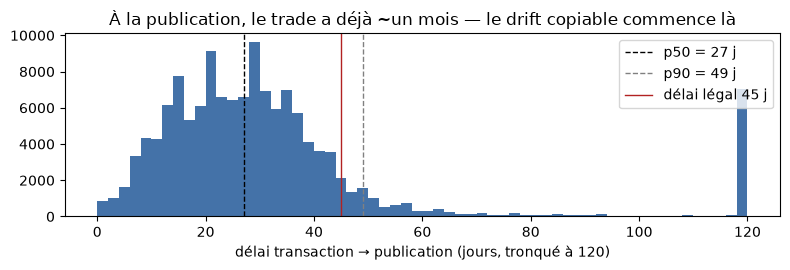

In [5]:
# La fenêtre W est motivée par le délai de publication : médiane 27 j, p90 49 j.
lag = (df["disclosure_date"] - df["transaction_date"]).dt.days
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.hist(lag.clip(0, 120), bins=60, color="#4472a8")
for q, c in [(0.5, "k"), (0.9, "grey")]:
    ax.axvline(lag.quantile(q), color=c, ls="--", lw=1,
               label=f"p{int(q*100)} = {lag.quantile(q):.0f} j")
ax.axvline(45, color="firebrick", lw=1, label="délai légal 45 j")
ax.set_xlabel("délai transaction → publication (jours, tronqué à 120)"); ax.legend()
ax.set_title("À la publication, le trade a déjà ~un mois — le drift copiable commence là")
plt.tight_layout(); plt.show()

In [6]:
# Déduplication GELÉE (§0.1) : natural_key_hash en double = re-dépôt identique du même trade.
n_avant = len(df)
df_flux = df.drop_duplicates(subset=["natural_key_hash"], keep="first").copy()
print(f"dédup natural_key_hash : {n_avant:,} → {len(df_flux):,} (−{n_avant - len(df_flux):,} re-dépôts identiques)")

# Le flux de la stratégie : actions seulement (asset_class gelé au §0.2), les deux sens (netting).
fl = df_flux[df_flux["asset_class"] == "stock"].copy()
fl["i_exec"] = CAL.searchsorted(pd.DatetimeIndex(fl["disclosure_date"]), side="right")
fl["col"] = fl["ticker_yahoo"].map(COL).fillna(-1).astype(int)
fl["A_signed"] = np.where(fl["direction"] == "buy", 1.0, -1.0) * fl["amount_midpoint"].astype(float)
print(f"flux stratégie : {len(fl):,} trades actions "
      f"(achats {(fl['direction'] == 'buy').sum():,} / ventes {(fl['direction'] == 'sell').sum():,})")

dédup natural_key_hash : 134,464 → 128,057 (−6,407 re-dépôts identiques)
flux stratégie : 122,957 trades actions (achats 62,184 / ventes 60,773)


## §2. Compléments de données (resumables, hors-ligne si les caches sont présents)

### §2.1 Volumes → ADV dollar (`cache/volume_v1/`)

L'ADV$^{63}$ (médiane 63 j de close **brut** × volume) sert trois fois : filtre de liquidité de l'univers,
pondération LW (proxy de taille point-in-time, corrélation log-log avec la capitalisation ≈ 0,9), et
analyse de capacité (§8). `auto_adjust=False` : le close ajusté des dividendes fausserait le dollar-volume
du yield cumulé (~×0,8 sur 12 ans) ; le produit close brut × volume est insensible aux splits (prix ÷ $k$,
volume × $k$).

In [7]:
# Téléchargement resumable — même patron que la cellule 4 du 06 ; cache complet = 0 réseau.
VOLUMES.mkdir(parents=True, exist_ok=True)
univers_vol = sorted(f.stem for f in PRICES.glob("*.csv") if f.stat().st_size > 200)
en_cache = {f.stem for f in VOLUMES.glob("*.csv") if f.stat().st_size > 100}
fichier_echecs = VOLUMES / "failed_volume.csv"
echecs_connus = set(pd.read_csv(fichier_echecs)["ticker"]) if fichier_echecs.exists() else set()
a_faire = [tk for tk in univers_vol if tk not in en_cache and tk not in echecs_connus]
print(f"{len(univers_vol)} symboles | en cache : {len(en_cache)} | échecs connus : {len(echecs_connus)} "
      f"| à télécharger : {len(a_faire)}")

if a_faire:
    import yfinance as yf
    for noisy in ("yfinance", "urllib3", "peewee"):
        logging.getLogger(noisy).setLevel(logging.CRITICAL)
    ok, fails = 0, []
    for i, tk in enumerate(a_faire, 1):
        got = False
        for attempt in range(3):
            try:
                h = yf.Ticker(tk).history(start="2012-01-01", auto_adjust=False)
                if len(h) >= 30 and "Volume" in h:
                    out = (h[["Close", "Volume"]]
                           .rename(columns={"Close": "close_raw", "Volume": "volume"}).reset_index())
                    out["Date"] = pd.to_datetime(out["Date"]).dt.date
                    out.to_csv(VOLUMES / f"{tk}.csv", index=False)
                    ok += 1; got = True
                break
            except Exception:
                time.sleep(1.5 * (attempt + 1))
        if not got:
            fails.append({"ticker": tk})
        if i % 250 == 0:
            print(f"  {i}/{len(a_faire)} | ok {ok} | échecs {len(fails)}", flush=True)
        time.sleep(0.25)
    anciens = pd.read_csv(fichier_echecs) if fichier_echecs.exists() else pd.DataFrame(columns=["ticker"])
    reussis = set(a_faire) - {f["ticker"] for f in fails}
    (pd.concat([anciens[~anciens["ticker"].isin(reussis)], pd.DataFrame(fails)])
       .drop_duplicates("ticker").to_csv(fichier_echecs, index=False))
    print(f"téléchargés : {ok} | échecs : {len(fails)} → failed_volume.csv à jour")
else:
    print("cache volume complet — aucun téléchargement (exécution hors-ligne)")

3351 symboles | en cache : 3309 | échecs connus : 43 | à télécharger : 0


cache volume complet — aucun téléchargement (exécution hors-ligne)


In [8]:
# Panel dollar-volume aligné sur CAL, mêmes colonnes que le panel prix.
def load_dv(tk):
    f = VOLUMES / f"{tk}.csv"
    if not f.exists() or f.stat().st_size < 100:
        return None
    v = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")
    return (v["close_raw"] * v["volume"]).rename(tk)

dv = pd.DataFrame({tk: s for tk in px.columns if (s := load_dv(tk)) is not None}).reindex(CAL)
DVV = dv.reindex(columns=px.columns).to_numpy()      # (T × N), NaN si volume absent
print(f"panel dollar-volume : {dv.shape[1]:,} / {px.shape[1]:,} tickers du panel prix")

# G0(b) — couverture du flux d'achat en dollars
buy = fl[fl["direction"] == "buy"]
flux_ok_px = buy["col"].ge(0)
a_dv = buy["ticker_yahoo"].isin(dv.columns)
w_usd = buy["amount_midpoint"].astype(float)
cov_px = (w_usd * flux_ok_px).sum() / w_usd.sum()
cov_dv = (w_usd * (flux_ok_px & a_dv)).sum() / w_usd.sum()
print(f"couverture du flux d'achat en $ : prix {cov_px:.1%} | prix+volume {cov_dv:.1%}")
assert cov_px >= 0.85, "G0(b) : couverture prix du flux < 85 %"
assert cov_dv >= 0.80, "G0(b) : couverture ADV du flux insuffisante"
print("G0(b) : OK")

panel dollar-volume : 3,247 / 3,289 tickers du panel prix
couverture du flux d'achat en $ : prix 89.0% | prix+volume 87.9%
G0(b) : OK


### §2.2 Facteurs — Carhart 4 (sur disque) + FF5 (Ken French), et preuve G0(a) de l'ajustement des prix

`cache/ff_factors.csv` = Mkt-RF, SMB, HML, RF, Mom quotidiens (Carhart 4, le modèle primaire).
`cache/ff5_factors.csv` (téléchargé une fois chez Ken French) ajoute RMW et CMA pour la robustesse.
**G0(a)** : si le cache prix était en close *non* ajusté, le SPY du cache aurait un alpha annuel
$\approx -$ le rendement du dividende ($\approx -1{,}3\,\%$/an) contre le facteur marché total-return.
On exige $|\alpha_{ann}| \le 0{,}5\,\%$, $|\beta - 1| \le 0{,}02$, $R^2 \ge 0{,}98$.

In [9]:
FF4 = pd.read_csv(HERE / "cache" / "ff_factors.csv", parse_dates=["Date"]).set_index("Date")
f5_path = HERE / "cache" / "ff5_factors.csv"
if not f5_path.exists():
    import urllib.request, zipfile, io as _io
    def ken_french(name):
        url = f"https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/{name}_CSV.zip"
        raw = urllib.request.urlopen(url, timeout=60).read()
        zf = zipfile.ZipFile(_io.BytesIO(raw))
        txt = zf.read(zf.namelist()[0]).decode("latin-1").splitlines()
        i0 = next(i for i, l in enumerate(txt) if l.strip()[:8].replace(",", "").isdigit())
        i1 = next((i for i in range(i0, len(txt))
                   if not txt[i].strip() or not txt[i].split(",")[0].strip().isdigit()), len(txt))
        d = pd.read_csv(_io.StringIO("\n".join([txt[i0 - 1]] + txt[i0:i1])))
        d = d.rename(columns={d.columns[0]: "Date"})
        d["Date"] = pd.to_datetime(d["Date"], format="%Y%m%d")
        return d.set_index("Date") / 100.0
    ff5 = ken_french("F-F_Research_Data_5_Factors_2x3_daily")
    mom = ken_french("F-F_Momentum_Factor_daily"); mom.columns = [c.strip() for c in mom.columns]
    ff5.join(mom["Mom"], how="inner").loc["2013":].to_csv(f5_path)
FF5 = pd.read_csv(f5_path, parse_dates=["Date"]).set_index("Date")
print(f"Carhart 4 : {FF4.index.min().date()} → {FF4.index.max().date()} | "
      f"FF5+MOM : {FF5.index.min().date()} → {FF5.index.max().date()}")

# oracle : les colonnes communes des deux fichiers concordent.
# SMB fait exception PAR CONSTRUCTION : le SMB « 3 facteurs » (tri Size×B/M) ≠ SMB « 5 facteurs »
# (moyenne des tris Size×{B/M, OP, INV}) → corr quotidienne ≈ 0,96, attendue et documentée.
comm = FF4.join(FF5, how="inner", lsuffix="_a", rsuffix="_b")
for c, seuil in [("Mkt-RF", 0.999), ("HML", 0.999), ("RF", 0.999), ("Mom", 0.999), ("SMB", 0.90)]:
    rho = np.corrcoef(comm[f"{c}_a"], comm[f"{c}_b"])[0, 1]
    assert rho > seuil, f"facteur {c} incohérent entre les deux fichiers (corr {rho:.4f})"
    if c == "SMB":
        print(f"SMB : corr {rho:.3f} — écart normal entre SMB(FF3) et SMB(FF5), constructions différentes")
print("cohérence ff_factors ↔ ff5_factors : OK (Mkt-RF/HML/RF/Mom > 0,999)")

Carhart 4 : 2013-01-02 → 2026-04-30 | FF5+MOM : 2013-01-02 → 2026-05-29
SMB : corr 0.956 — écart normal entre SMB(FF3) et SMB(FF5), constructions différentes
cohérence ff_factors ↔ ff5_factors : OK (Mkt-RF/HML/RF/Mom > 0,999)


In [10]:
# G0(a) — preuve que prices_v2 est en adjusted close (dividendes + splits), en deux temps.
# (1) Test DIRECT : croissance totale du SPY (cache, ajusté) vs croissance prix-seul (close brut
#     de volume_v1). Le ratio = les dividendes réinvestis cumulés (~+25-30 % sur 2012-2026).
spy_raw = pd.read_csv(VOLUMES / "SPY.csv", parse_dates=["Date"]).set_index("Date")["close_raw"]
com = pd.concat([spy.rename("adj"), spy_raw.rename("raw")], axis=1).dropna()
ratio = (com["adj"].iloc[-1] / com["adj"].iloc[0]) / (com["raw"].iloc[-1] / com["raw"].iloc[0])
print(f"croissance SPY cache / croissance prix-seul ({com.index[0].date()} → {com.index[-1].date()}) : "
      f"{ratio:.3f} (≈ dividendes réinvestis ; = 1,000 si le cache était en close brut)")
assert 1.15 < ratio < 1.60, "G0(a1) échoué : le cache ne contient pas les dividendes"

# (2) Sanity d'alignement : SPY vs facteur marché CRSP (marché TOTAL, small caps incluses →
#     β attendu ≈ 0,96, PAS 1,00 ; c'est le spread S&P 500 / marché total, pas un défaut de données).
r_spy_d = spy.pct_change().dropna()
g0 = pd.DataFrame({"y": r_spy_d}).join(FF4[["Mkt-RF", "RF"]], how="inner").dropna()
y = (g0["y"] - g0["RF"]).to_numpy()
X = np.column_stack([np.ones(len(g0)), g0["Mkt-RF"].to_numpy()])
bh = np.linalg.lstsq(X, y, rcond=None)[0]
r2 = 1 - (y - X @ bh).var() / y.var()
alpha_ann, beta = bh[0] * 252, bh[1]
print(f"r_SPY(cache) − rf ~ Mkt-RF (CRSP total) : α = {alpha_ann:+.2%}/an, β = {beta:.4f}, R² = {r2:.4f}")
assert 0.93 <= beta <= 1.02 and abs(alpha_ann) <= 0.01 and r2 >= 0.98, "G0(a2) échoué : désalignement facteurs/prix"
print("G0(a) : OK — cache en adjusted close, facteurs alignés")

croissance SPY cache / croissance prix-seul (2012-01-03 → 2026-07-02) : 1.287 (≈ dividendes réinvestis ; = 1,000 si le cache était en close brut)
r_SPY(cache) − rf ~ Mkt-RF (CRSP total) : α = +0.40%/an, β = 0.9633, R² = 0.9894
G0(a) : OK — cache en adjusted close, facteurs alignés


### §2.3 Matrice comité → GICS (celle du §0.5, en code) et filtre CI

Le contrôle anti-circularité : la **part de flux « aligné »** est regardée ici, avant tout rendement.

In [11]:
SECTEURS = ["Information Technology", "Financials", "Health Care", "Industrials",
            "Consumer Discretionary", "Communication Services", "Consumer Staples",
            "Energy", "Materials", "Real Estate", "Utilities"]

COMITE_GICS = {   # gelée au §0.5 — chaque ligne justifiée par le champ jurisdiction officiel
    "HSAG": {"Consumer Staples", "Materials"},          "SSAF": {"Consumer Staples", "Materials"},
    "HSAS": {"Industrials"},  "SSAS": {"Industrials"},  "HLIG": {"Industrials"},
    "HSHM": {"Industrials", "Information Technology"},
    "HSBA": {"Financials", "Real Estate"},              "SSBK": {"Financials", "Real Estate"},
    "HSIF": {"Energy", "Utilities", "Health Care", "Communication Services"},
    "HSII": {"Energy", "Materials", "Utilities"},       "SSEG": {"Energy", "Utilities", "Materials"},
    "SSEV": {"Utilities", "Materials", "Industrials"},  "HSPW": {"Industrials", "Utilities"},
    "SSCM": {"Industrials", "Communication Services", "Information Technology"},
    "HSWM": {"Health Care", "Financials"},              "SSFI": {"Health Care", "Financials"},
    "HSSY": {"Information Technology"},                 "SSHR": {"Health Care"},
    "HSVR": {"Health Care"},
    # transverses → ∅ (les inclure viderait « aligné » de son sens)
    "HSAP": set(), "SSAP": set(), "HSGO": set(), "SSGA": set(), "HSRU": set(), "HSHA": set(),
    "HSJU": set(), "SSJU": set(), "HSFA": set(), "SSFR": set(), "HSSM": set(), "HSED": set(),
}

import re
def codes_racine(s):
    if not isinstance(s, str):
        return frozenset()
    return frozenset(t.strip()[:4] for t in s.split(";") if re.fullmatch(r"[A-Z]{4}\d*", t.strip()))

fl["codes"] = fl["committee_membership"].map(codes_racine)
fl["secteurs_membre"] = fl["codes"].map(lambda cs: frozenset().union(*[COMITE_GICS.get(c, set()) for c in cs])
                                        if cs else frozenset())
fl["ci"] = [s in sm for s, sm in zip(fl["sector_gics"], fl["secteurs_membre"])]

part_ci = fl.loc[fl["direction"] == "buy", "ci"].mean()
part_ci_usd = fl.loc[fl["direction"] == "buy"].groupby("ci")["amount_midpoint"].sum()
print(f"part des ACHATS « alignés comité×secteur » : {part_ci:.1%} (en $ : "
      f"{part_ci_usd.get(True, 0) / part_ci_usd.sum():.1%})")
assert part_ci < 0.70, "matrice trop lâche (>70 % alignés) — elle aurait dû être resserrée AVANT tout backtest"

part des ACHATS « alignés comité×secteur » : 17.0% (en $ : 15.2%)


In [12]:
# Validation à la main : 5 trades tirés au sort (seed gelée), le flag CI se lit ligne à ligne.
ech = fl[fl["direction"] == "buy"].sample(5, random_state=42)
for _, r in ech.iterrows():
    print(f"{r['member_name'][:24]:24s} {str(r['ticker_yahoo']):6s} secteur={str(r['sector_gics'])[:22]:22s} "
          f"comités={sorted(r['codes'])} → CI={r['ci']}")
# et deux cas construits : membre de Financial Services (HSBA) × titre Financials → CI=True, toujours
hsba = fl[(fl["codes"].map(lambda c: "HSBA" in c)) & (fl["sector_gics"] == "Financials")]
hsba_off = fl[(fl["codes"].map(lambda c: "HSBA" in c))
              & (fl["secteurs_membre"].map(lambda s: "Consumer Staples" not in s))
              & (fl["sector_gics"] == "Consumer Staples")]
assert hsba["ci"].all() and not hsba_off["ci"].any()
print(f"\ncontrôles construits : membre HSBA × Financials → CI=True ({len(hsba):,} cas) ; "
      f"même membre × Consumer Staples (hors juridictions) → CI=False ({len(hsba_off):,} cas) — OK")

Rohit Khanna             WELL   secteur=Real Estate            comités=['HSAG', 'HSAS', 'HSGO'] → CI=False
Earl Blumenauer          PHG    secteur=Health Care            comités=['HSWM'] → CI=True
Susie Lee                SWK    secteur=Industrials            comités=['HSAP'] → CI=False
Michael T. McCaul        APA    secteur=Energy                 comités=['HSFA', 'HSHM', 'HSSY'] → CI=False
Rohit Khanna             PINS   secteur=Communication Services comités=['HSAS', 'HSGO'] → CI=False

contrôles construits : membre HSBA × Financials → CI=True (1,216 cas) ; même membre × Consumer Staples (hors juridictions) → CI=False (632 cas) — OK


## §3. Le moteur calendar-time — machinerie complète, validée AVANT la pause

Tout l'outillage de §4-§10 est défini et validé **ici** (sur données synthétiques et sur des propriétés,
jamais sur un rendement de stratégie réel). Après la pause chef, les sections 4+ ne font qu'**appliquer**
ces fonctions aux vraies données.

**Le moteur à segments** : entre deux rebalancements les poids driftent — la NAV d'un panier à parts
constantes se calcule d'un bloc par produit cumulé, ce qui rend chaque backtest quasi instantané
(nécessaire pour $B = 1000$ placebos) :
$$V_i(\tau) = w_i \prod_{u \le \tau}(1 + r_{i,u}), \qquad r^p(\tau) = \frac{V(\tau)}{V(\tau-1)} - 1,
\qquad w^{drift}_i(\text{fin}) = \frac{V_i(\text{fin})}{V(\text{fin})}$$
Conventions : le coût du rebalancement au close de $t$ est payé dans $r^{net}(t)$ du même jour
(convention du moteur du 06) ; le premier jour de la série est le premier rebalancement
($r^p = 0$, $\mathrm{TO} = 1$ : le coût d'entrée).

In [13]:
# ── Rebalancements : dernier jour de bourse de chaque mois, du burn-in commun à la fin gelée.
def fin_de_mois(cal, debut, fin):
    s = pd.Series(np.arange(len(cal)), index=cal)
    rebs = s.groupby([cal.year, cal.month]).last().to_numpy()
    lo, hi = cal.searchsorted(pd.Timestamp(debut)), cal.searchsorted(pd.Timestamp(fin), side="right") - 1
    return rebs[(rebs >= lo) & (rebs <= hi)]

REBS = fin_de_mois(CAL, PARAMS["REB_PREMIER"], PARAMS["REB_DERNIER"])
I_FIN = int(CAL.searchsorted(pd.Timestamp(PARAMS["EVAL_FIN"]), side="right") - 1)
assert len(REBS) == 143, f"attendu 143 rebalancements (2014-06 → 2026-04), obtenu {len(REBS)}"
print(f"{len(REBS)} rebalancements mensuels : {CAL[REBS[0]].date()} → {CAL[REBS[-1]].date()} "
      f"| évaluation jusqu'au {CAL[I_FIN].date()}")

143 rebalancements mensuels : 2014-06-30 → 2026-04-30 | évaluation jusqu'au 2026-05-29


In [14]:
# ── Univers point-in-time aux rebalancements : ≥126 prix observés, prix frais (≤5 j), ADV ≥ seuil.
OBS = ~np.isnan(PXV)
CUMOBS = OBS.cumsum(axis=0)
N = px.shape[1]

def univers_et_adv(rebs, adv_min):
    ok = np.zeros((len(rebs), N), bool)
    adv = np.full((len(rebs), N), np.nan)
    for j, i in enumerate(rebs):
        assez_obs = CUMOBS[i] >= 126
        frais = OBS[max(0, i - 4): i + 1].any(axis=0)
        fen = DVV[max(0, i - 62): i + 1]
        n_ok = (~np.isnan(fen)).sum(axis=0)
        with np.errstate(all="ignore"):
            a = np.nanmedian(fen, axis=0)
        a[n_ok < 32] = np.nan                       # ≥ la moitié de la fenêtre ADV observée
        adv[j] = a
        ok[j] = assez_obs & frais & (a >= adv_min)
    return ok, adv

UNIV_OK, ADV_REB = univers_et_adv(REBS, PARAMS["ADV_MIN"])
print(f"univers médian au rebalancement : {int(np.median(UNIV_OK.sum(axis=1))):,} titres "
      f"(min {UNIV_OK.sum(axis=1).min():,}, max {UNIV_OK.sum(axis=1).max():,})")

univers médian au rebalancement : 1,829 titres (min 1,366, max 2,202)


In [15]:
# ── Cap itératif (§0.2) : une passe peut repousser d'autres poids au-dessus du cap → on itère.
# Cap infaisable (n × w_max < 1, ex. mois maigre sous filtre Spec/CI) : chaque nom reçoit w_max,
# LE SOLDE RESTE EN CASH (rendement 0) — on ne viole jamais le cap.
def cap_renorm(w, w_max):
    w = np.asarray(w, float).copy()
    s = w.sum()
    if s <= 0:
        return w * 0.0
    w /= s
    if w_max * (w > 0).sum() < 1.0 - 1e-12:
        return np.where(w > 0, w_max, 0.0)           # solde en cash
    fixes = np.zeros(len(w), bool)
    for _ in range(len(w)):
        exces = (w > w_max + 1e-15) & ~fixes
        if not exces.any():
            break
        fixes |= exces
        w[fixes] = w_max
        reste = 1.0 - w_max * fixes.sum()
        libre = ~fixes & (w > 0)
        if libre.any():
            w[libre] *= reste / w[libre].sum()
    return w

# validation par force brute sur 2 000 tirages aléatoires
rng = np.random.default_rng(0)
for _ in range(2000):
    v = rng.pareto(1.5, size=rng.integers(2, 60)) + 1e-9
    w = cap_renorm(v, 0.10)
    assert w.max() <= 0.10 + 1e-9 and (w >= 0).all()
    if (v > 0).sum() * 0.10 >= 1.0:
        assert abs(w.sum() - 1) < 1e-9               # cap faisable : entièrement investi
    else:
        assert np.allclose(w[w > 0], 0.10) and w.sum() <= 1.0   # infaisable : w_max chacun + cash
    ordre = np.argsort(-v)
    assert (np.diff(w[ordre]) <= 1e-12).all()        # l'ordre des poids est préservé
print("cap_renorm : max ≤ w_max, investi ou w_max+cash, ordre préservé — 2 000 tirages OK")

cap_renorm : max ≤ w_max, investi ou w_max+cash, ordre préservé — 2 000 tirages OK


In [16]:
# ── Filtres qualité au niveau trade (§0.2) : CI est une colonne ; Spec dépend du rebalancement.
FL_IEXEC = fl["i_exec"].to_numpy()
FL_COL = fl["col"].to_numpy()
FL_AS = fl["A_signed"].to_numpy()
FL_CI = fl["ci"].to_numpy()
_g_codes, FL_G = np.unique(fl["bioguide_id"].astype(str) + "|" + fl["ticker_yahoo"].astype(str),
                           return_inverse=True)
_buy = fl["direction"].to_numpy() == "buy"
_execs_b = {g: np.sort(FL_IEXEC[(FL_G == g) & _buy]) for g in np.unique(FL_G[_buy])}
_execs_s = {g: np.sort(FL_IEXEC[(FL_G == g) & ~_buy]) for g in np.unique(FL_G[~_buy])}

def masque_filtre(m_fenetre, i_reb, filtre):
    """Restreint le masque de fenêtre aux trades qualifiés par le filtre pré-enregistré."""
    if filtre == "tous":
        return m_fenetre
    if filtre == "CI":
        return m_fenetre & FL_CI
    if filtre == "Spec":                              # couple (m,i) avec achat ET vente sur (i−252, i]
        ok_g = set()
        for g in np.unique(FL_G[m_fenetre]):
            eb, es = _execs_b.get(g), _execs_s.get(g)
            if eb is None or es is None:
                continue
            nb = np.searchsorted(eb, i_reb, "right") - np.searchsorted(eb, i_reb - 252, "right")
            ns = np.searchsorted(es, i_reb, "right") - np.searchsorted(es, i_reb - 252, "right")
            if nb > 0 and ns > 0:
                ok_g.add(g)
        return m_fenetre & np.isin(FL_G, list(ok_g))
    raise ValueError(filtre)
print(f"{len(_g_codes):,} couples (membre, ticker) indexés pour le filtre Spec")

22,366 couples (membre, ticker) indexés pour le filtre Spec


In [17]:
# ── Cibles : NetBuy par ticker sur la fenêtre, univers, pondération, cap.
# Modes : LW = ADV-weighted (primaire) | SW = log(1+NetBuy) | EW = équi (diagnostic) | MID = NetBuy brut (diagnostic)
def construire_cibles(W, mode, filtre, i_exec=None, col=None, a_signed=None,
                      univ_ok=None, adv_reb=None, rebs=None, w_max=None):
    """Matrice (n_rebs × N) des poids cibles. Tous les intrants sont surchargables (placebos, diagnostics)."""
    i_exec = FL_IEXEC if i_exec is None else i_exec
    col = FL_COL if col is None else col
    a_signed = FL_AS if a_signed is None else a_signed
    univ_ok = UNIV_OK if univ_ok is None else univ_ok
    adv_reb = ADV_REB if adv_reb is None else adv_reb
    rebs = REBS if rebs is None else rebs
    w_max = PARAMS["W_MAX"] if w_max is None else w_max
    Wt = np.zeros((len(rebs), N))
    for j, i in enumerate(rebs):
        m = (i_exec > i - W) & (i_exec <= i) & (col >= 0)
        m = masque_filtre(m, i, filtre)
        net = np.zeros(N)
        np.add.at(net, col[m], a_signed[m])
        net = np.maximum(net, 0.0)                    # NetBuy = [Buy − Sell]+
        elig = (net > 0) & univ_ok[j]
        if mode == "LW":
            base = np.where(elig, adv_reb[j], 0.0)
        elif mode == "SW":
            base = np.where(elig, np.log1p(net), 0.0)
        elif mode == "EW":
            base = elig.astype(float)
        elif mode == "MID":
            base = np.where(elig, net, 0.0)
        else:
            raise ValueError(mode)
        base = np.nan_to_num(base, nan=0.0)
        if base.sum() > 0:
            Wt[j] = cap_renorm(base, w_max)
    return Wt

In [18]:
# ── Le moteur à segments. Rendements ffillés (délistés : dernier prix connu, convention 06/§4).
PXF = px.ffill().to_numpy()
with np.errstate(all="ignore"):
    G1P = np.nan_to_num(PXF[1:] / PXF[:-1], nan=1.0)   # 1 + r du jour CAL[t+1] en ligne t
G1P[G1P <= 0] = 1.0

def moteur_calendar(Wt, rebs=None, i_fin=None):
    """Série quotidienne du portefeuille rebalancé aux indices `rebs` vers les poids `Wt`.
    La série commence AU premier rebalancement (r=0, TO=1 : coût d'entrée le jour même).
    Renvoie (r_brut Series, TO Series aux rebalancements, segs pour ω sectoriels/capacité)."""
    rebs = REBS if rebs is None else rebs
    i_fin = I_FIN if i_fin is None else i_fin
    idx = CAL[rebs[0]: i_fin + 1]
    r_brut = np.zeros(len(idx))
    TO = pd.Series(0.0, index=CAL[rebs])
    bornes = list(rebs) + [i_fin]
    w = np.zeros(N if Wt.shape[1] == N else Wt.shape[1])
    segs = []
    for j in range(len(rebs)):
        TO.iloc[j] = np.abs(Wt[j] - w).sum()
        w = Wt[j].copy()
        a, b = bornes[j], bornes[j + 1]
        if b <= a:
            continue
        actifs = np.flatnonzero(w > 0)
        cash = 1.0 - w.sum()                           # solde non investi (cap infaisable) : rendement 0
        if len(actifs):
            cum = np.cumprod(G1P[a:b][:, actifs], axis=0)   # jours CAL[a+1 .. b]
            V = w[actifs] * cum                        # (L × n_actifs)
            Vt = V.sum(axis=1) + cash                  # valeur totale, cash inclus
            r_seg = np.diff(np.concatenate([[1.0], Vt])) / np.concatenate([[1.0], Vt[:-1]])
            segs.append((a, actifs, w[actifs].copy(), V, Vt))
            w = np.zeros(len(w)); w[actifs] = V[-1] / Vt[-1]
        else:
            r_seg = np.zeros(b - a)
            segs.append((a, actifs, None, None, None))
        r_brut[a + 1 - rebs[0]: b + 1 - rebs[0]] = r_seg
    return pd.Series(r_brut, index=idx), TO, segs

def rendement_net(r_brut, TO, c):
    """(1+r)(1−c·TO)−1 le jour du rebalancement (le coût d'entrée tombe sur le 1er jour de la série)."""
    to_al = TO.reindex(r_brut.index).fillna(0.0)
    return (1 + r_brut) * (1 - c * to_al) - 1

In [19]:
# ── §3.1 Validation oracle : moteur à segments vs boucle naïve jour par jour, données SYNTHÉTIQUES.
rng = np.random.default_rng(7)
n_syn, T_syn = 6, 260
px_syn = pd.DataFrame(100 * np.exp(np.cumsum(rng.normal(0, 0.02, (T_syn, n_syn)), axis=0)),
                      index=CAL[:T_syn], columns=[f"S{i}" for i in range(n_syn)])
rebs_syn = fin_de_mois(CAL[:T_syn], CAL[10], CAL[T_syn - 30])
Wt_syn = np.zeros((len(rebs_syn), n_syn))
for j in range(len(rebs_syn)):
    v = rng.pareto(1.2, n_syn) * (rng.random(n_syn) > 0.3)
    Wt_syn[j] = cap_renorm(v, 0.5) if v.sum() > 0 else 0.0
    if j % 3 == 1:
        Wt_syn[j] *= 0.6                               # teste la poche de cash (Σw < 1)

_sauve = (PXF, G1P, N)
PXF = px_syn.to_numpy(); G1P = PXF[1:] / PXF[:-1]; N = n_syn
r_moteur, TO_moteur, _ = moteur_calendar(Wt_syn, rebs=rebs_syn, i_fin=T_syn - 5)
PXF, G1P, N = _sauve

# la boucle naïve, jour par jour (mêmes conventions)
P = px_syn.to_numpy()
reb_map = {int(i): j for j, i in enumerate(rebs_syn)}
w = np.zeros(n_syn); r_naif, to_naif = [], []
for t in range(int(rebs_syn[0]), T_syn - 5 + 1):
    if t == int(rebs_syn[0]):
        r_day = 0.0
    else:
        r = P[t] / P[t - 1] - 1
        r_day = float(w @ r)
        if w.sum() > 0:
            w = w * (1 + r) / (1 + r_day)
    to = 0.0
    if t in reb_map:
        to = float(np.abs(Wt_syn[reb_map[t]] - w).sum()); w = Wt_syn[reb_map[t]].copy()
    r_naif.append(r_day); to_naif.append(to)
ecart_r = np.abs(r_moteur.to_numpy() - np.array(r_naif)).max()
ecart_to = np.abs(TO_moteur.to_numpy() - np.array([to_naif[int(i) - int(rebs_syn[0])] for i in rebs_syn])).max()
print(f"moteur segments vs boucle naïve (synthétique {n_syn} titres × {T_syn} j) : "
      f"écart max r = {ecart_r:.2e}, écart max TO = {ecart_to:.2e}")
assert ecart_r < 1e-12 and ecart_to < 1e-12
print("oracle moteur : OK (< 1e-12)")

moteur segments vs boucle naïve (synthétique 6 titres × 260 j) : écart max r = 3.82e-16, écart max TO = 5.55e-16
oracle moteur : OK (< 1e-12)


In [20]:
# ── §3.2 Contrôle dégénéré : 1 titre, poids 1 → la NAV nette redonne le buy-and-hold au coût près.
Wt_un = np.zeros((len(REBS), N)); Wt_un[:, COL["AAPL"]] = 1.0
r_un, TO_un, _ = moteur_calendar(Wt_un)
nav_un = float((1 + rendement_net(r_un, TO_un, 0.001)).prod())
bh = float(PXF[I_FIN, COL["AAPL"]] / PXF[REBS[0], COL["AAPL"]])
print(f"NAV nette 1 titre (AAPL, c = 10 bps) {nav_un:.4f} vs buy-and-hold × (1−c) {bh * (1 - 0.001):.4f}")
assert abs(nav_un - bh * (1 - 0.001)) / bh < 1e-9
assert float(TO_un.iloc[0]) == 1.0 and float(TO_un.iloc[1:].abs().max()) < 1e-12
print("contrôle dégénéré : OK (TO = 1 à l'entrée, 0 ensuite, NAV = B&H × (1−c))")

NAV nette 1 titre (AAPL, c = 10 bps) 15.3016 vs buy-and-hold × (1−c) 15.3016
contrôle dégénéré : OK (TO = 1 à l'entrée, 0 ensuite, NAV = B&H × (1−c))


In [21]:
# ── §3.3 Newey-West à la main vs statsmodels (oracle sur données simulées, AVANT tout usage réel).
def nw_tstat(y, X, L):
    """OLS + erreurs HAC Bartlett(L). Renvoie (beta, t, se, resid)."""
    y = np.asarray(y, float); X = np.asarray(X, float)
    Tn = len(y)
    XtX_inv = np.linalg.inv(X.T @ X)
    beta = XtX_inv @ X.T @ y
    u = y - X @ beta
    Xu = X * u[:, None]
    S = Xu.T @ Xu / Tn
    for l in range(1, L + 1):
        G = Xu[l:].T @ Xu[:-l] / Tn
        S += (1 - l / (L + 1)) * (G + G.T)
    V = Tn * XtX_inv @ S @ XtX_inv
    se = np.sqrt(np.diag(V))
    return beta, beta / se, se, u

import statsmodels.api as sm
rng = np.random.default_rng(123)
Xs = np.column_stack([np.ones(600), rng.normal(size=(600, 3))])
ys = Xs @ np.array([0.001, 0.5, -0.2, 0.1]) + np.convolve(rng.normal(size=620), np.ones(8) / 8, "valid")[:600]
b_h, t_h, se_h, _ = nw_tstat(ys, Xs, 21)
res_sm = sm.OLS(ys, Xs).fit(cov_type="HAC", cov_kwds={"maxlags": 21, "use_correction": False})
assert np.abs(b_h - res_sm.params).max() < 1e-10 and np.abs(t_h - res_sm.tvalues).max() < 1e-8
print(f"NW à la main vs statsmodels HAC(21) : Δβ max {np.abs(b_h - res_sm.params).max():.1e}, "
      f"Δt max {np.abs(t_h - res_sm.tvalues).max():.1e} — OK")

NW à la main vs statsmodels HAC(21) : Δβ max 5.6e-17, Δt max 1.6e-14 — OK


In [22]:
# ── Évaluation : α Carhart-4 quotidien (NW L=21) + version mensuelle (NW L=6) + IR.
F4 = FF4.reindex(CAL).dropna()                        # facteurs aux jours communs (pas de ffill de facteurs)

def alpha_c4(r_net, lag=None, facteurs=None):
    lag = PARAMS["NW_LAG_J"] if lag is None else lag
    F = F4 if facteurs is None else facteurs
    dat = pd.DataFrame({"r": r_net}).join(F, how="inner").dropna()
    cols = [c for c in ["Mkt-RF", "SMB", "HML", "RMW", "CMA", "Mom"] if c in dat.columns]
    y = (dat["r"] - dat["RF"]).to_numpy()
    X = np.column_stack([np.ones(len(dat)), dat[cols].to_numpy()])
    beta, t, se, u = nw_tstat(y, X, lag)
    return {"alpha_ann": beta[0] * 252, "t": float(t[0]), "betas": dict(zip(cols, np.round(beta[1:], 3))),
            "sigma_eps_m": float(u.std() * np.sqrt(21)), "n_jours": len(dat), "resid": u,
            "dates": dat.index}

def en_mensuel(r):
    g = (1 + r).groupby([r.index.year, r.index.month]).prod() - 1
    g.index = pd.PeriodIndex([f"{y}-{m:02d}" for y, m in g.index], freq="M")
    return g

def alpha_c4_mensuel(r_net):
    rm = en_mensuel(r_net)
    Fm = pd.concat([en_mensuel(F4[c]) for c in ["Mkt-RF", "SMB", "HML", "Mom", "RF"]], axis=1,
                   keys=["Mkt-RF", "SMB", "HML", "Mom", "RF"])
    dat = pd.concat([rm.rename("r"), Fm], axis=1).dropna()
    y = (dat["r"] - dat["RF"]).to_numpy()
    X = np.column_stack([np.ones(len(dat)), dat[["Mkt-RF", "SMB", "HML", "Mom"]].to_numpy()])
    beta, t, se, u = nw_tstat(y, X, PARAMS["NW_LAG_M"])
    return {"alpha_m": float(beta[0]), "t": float(t[0]), "n_mois": len(dat),
            "sigma_eps_m": float(u.std())}

def ir(x):
    x = x.dropna()
    return float(x.mean() / x.std() * np.sqrt(252)) if x.std() > 0 else np.nan

r_spy = spy.pct_change()
r_qqq = load_price("QQQ").reindex(CAL).pct_change()
print("outillage d'évaluation défini (alpha_c4, alpha_c4_mensuel, en_mensuel, ir)")

outillage d'évaluation défini (alpha_c4, alpha_c4_mensuel, en_mensuel, ir)


In [23]:
# ── Benchmark composite sectoriel auto-répliquant (§0.3) : ω_{s,t} = poids sectoriels du portefeuille.
XLS = {"Information Technology": "XLK", "Financials": "XLF", "Health Care": "XLV", "Industrials": "XLI",
       "Consumer Discretionary": "XLY", "Communication Services": "XLC", "Consumer Staples": "XLP",
       "Energy": "XLE", "Materials": "XLB", "Real Estate": "XLRE", "Utilities": "XLU"}
sect_tk = df_flux.groupby("ticker_yahoo")["sector_gics"].agg(
    lambda s: s.mode().iloc[0] if s.notna().any() else np.nan)
SECT = np.zeros((N, len(SECTEURS) + 1))               # colonne 12 = « sans GICS » → repli SPY
for tk, i in COL.items():
    s = sect_tk.get(tk, np.nan)
    SECT[i, SECTEURS.index(s) if isinstance(s, str) and s in SECTEURS else len(SECTEURS)] = 1.0
rXL = pd.DataFrame({s: load_price(e).reindex(CAL).pct_change() for s, e in XLS.items()})
rXL["_SPY_"] = r_spy
rXL = rXL[[*SECTEURS, "_SPY_"]]
RXL = rXL.to_numpy()
RXL = np.where(np.isnan(RXL), rXL["_SPY_"].to_numpy()[:, None], RXL)   # XLC/XLRE jeunes : repli SPY
RXL = np.nan_to_num(RXL, nan=0.0)                                      # 1er jour (pct_change) → 0

def bench_sectoriel(segs, rebs=None, i_fin=None):
    """r_sect(t) = Σ_s ω_{s,t−1} · r_{XL_s}(t) — même mix sectoriel que le portefeuille, jour par jour."""
    rebs = REBS if rebs is None else rebs
    i_fin = I_FIN if i_fin is None else i_fin
    idx = CAL[rebs[0]: i_fin + 1]
    out = np.zeros(len(idx))
    for (a, act, w0, V, Vt) in segs:
        if V is None or len(act) == 0:
            continue
        om = SECT[act].T @ w0                          # ω au close du rebalancement a
        for h in range(len(Vt)):                       # rendement du jour CAL[a+1+h]
            out[a + 1 + h - rebs[0]] = float(om @ RXL[a + 1 + h])
            om = SECT[act].T @ (V[h] / Vt[h])
    return pd.Series(out, index=idx)
print("benchmark sectoriel défini (repli SPY quand l'ETF n'existe pas encore)")

benchmark sectoriel défini (repli SPY quand l'ETF n'existe pas encore)


In [24]:
# ── Le tout-en-un : une configuration = cibles → moteur → net → α. Smoke-test SYNTHÉTIQUE.
def run_config(W, mode, filtre, c=None, i_exec=None, col=None, a_signed=None, avec_sect=False,
               univ_ok=None, adv_reb=None, rebs=None, w_max=None):
    c = PARAMS["COUT_DECISION"] if c is None else c
    Wt = construire_cibles(W, mode, filtre, i_exec=i_exec, col=col, a_signed=a_signed,
                           univ_ok=univ_ok, adv_reb=adv_reb, rebs=rebs, w_max=w_max)
    r_brut, TO, segs = moteur_calendar(Wt, rebs=rebs)
    r_net = rendement_net(r_brut, TO, c)
    out = {"W": W, "mode": mode, "filtre": filtre, "c": c, "r_brut": r_brut, "r_net": r_net,
           "TO": TO, "Wt": Wt, "segs": segs,
           "to_an": float(TO.iloc[1:].mean() * 12), "n_noms_med": float(np.median((Wt > 0).sum(axis=1)))}
    if avec_sect:
        out["r_sect"] = bench_sectoriel(segs, rebs=rebs)
    return out

# smoke-test sur flux SYNTHÉTIQUE : 400 faux trades sur 30 vrais tickers liquides.
rng = np.random.default_rng(99)
liquides = np.flatnonzero(UNIV_OK[0])[:30]
n_fake = 400
fake = (rng.integers(REBS[0] - 200, REBS[-1], n_fake),
        rng.choice(liquides, n_fake),
        rng.choice([1.0, -1.0], n_fake, p=[0.7, 0.3]) * (rng.pareto(1.5, n_fake) + 0.1) * 8000)
cfg_syn = run_config(21, "LW", "tous", i_exec=fake[0], col=fake[1], a_signed=fake[2], avec_sect=True)
al_syn = alpha_c4(cfg_syn["r_net"])
_ = alpha_c4_mensuel(cfg_syn["r_net"])
assert np.isfinite(al_syn["alpha_ann"]) and np.isfinite(al_syn["t"])
assert np.nan_to_num(cfg_syn["Wt"]).max() <= PARAMS["W_MAX"] + 1e-9
assert len(cfg_syn["r_sect"]) == len(cfg_syn["r_brut"])
print(f"smoke-test flux synthétique : {cfg_syn['n_noms_med']:.0f} noms médians, "
      f"turnover {cfg_syn['to_an']:.1f}×/an, α et t finis, cap respecté — la chaîne complète tourne.")

smoke-test flux synthétique : 1 noms médians, turnover 3.6×/an, α et t finis, cap respecté — la chaîne complète tourne.


In [25]:
# ── Placebos (définis et smoke-testés ici, appliqués au §9).
def placebo_p1(rng):
    """Dates décalées : i_exec + U{63..252} — l'info devient périmée, un vrai signal meurt."""
    return FL_IEXEC + rng.integers(63, 253, len(FL_IEXEC)), FL_COL, FL_AS

def placebo_p2(rng):
    """Tickers permutés dans {GICS × mois d'exec × tercile ADV} — détruit la sélection, garde les flux."""
    mois = np.clip(np.searchsorted(REBS, FL_IEXEC, "left"), 0, len(REBS) - 1)
    sect = np.array([int(np.argmax(SECT[c])) if c >= 0 else -1 for c in FL_COL])
    adv_t = np.where(FL_COL >= 0, ADV_REB[mois, np.maximum(FL_COL, 0)], np.nan)
    ter = np.full(len(FL_COL), -1)
    fini = np.isfinite(adv_t)
    q1, q2 = np.nanquantile(adv_t[fini], [1 / 3, 2 / 3])
    ter[fini] = np.digitize(adv_t[fini], [q1, q2])
    col_new = FL_COL.copy()
    cle = mois * 1000 + sect * 10 + ter
    for c in np.unique(cle[(FL_COL >= 0) & (sect >= 0) & (ter >= 0)]):
        m = np.flatnonzero((cle == c) & (FL_COL >= 0) & (sect >= 0) & (ter >= 0))
        if len(m) > 1:
            col_new[m] = FL_COL[m][rng.permutation(len(m))]
    return FL_IEXEC, col_new, FL_AS

def placebo_p4(rng):
    """Montants permutés dans le mois — si α inchangé, la « conviction » ne pesait rien."""
    mois = np.clip(np.searchsorted(REBS, FL_IEXEC, "left"), 0, len(REBS) - 1)
    signe, ampl = np.sign(FL_AS), np.abs(FL_AS).copy()
    for m_ in np.unique(mois):
        idx = np.flatnonzero(mois == m_)
        if len(idx) > 1:
            ampl[idx] = ampl[idx][rng.permutation(len(idx))]
    return FL_IEXEC, FL_COL, signe * ampl

def t_alpha(i_exec, col, a_signed, W, mode):
    cfg = run_config(W, mode, "tous", i_exec=i_exec, col=col, a_signed=a_signed)
    return alpha_c4(cfg["r_net"])["t"]

rng0 = np.random.default_rng(1)
for f_ in (placebo_p1, placebo_p2, placebo_p4):
    ie, co, am = f_(rng0)
    assert len(ie) == len(FL_IEXEC) and len(co) == len(FL_COL) and len(am) == len(FL_AS)
print("placebos P1/P2/P4 : transformations définies et dimensionnellement valides")

placebos P1/P2/P4 : transformations définies et dimensionnellement valides


In [26]:
# ── Monte-Carlo E[max t | H0] : la formule de Gumbel du §0.4, validée par simulation.
def e_max_t(NN):
    from scipy.stats import norm
    g = 0.5772156649
    return (1 - g) * norm.ppf(1 - 1 / NN) + g * norm.ppf(1 - 1 / (NN * np.e))

rng = np.random.default_rng(2)
mx_signe = rng.normal(size=(100_000, PARAMS["N_TESTS"])).max(axis=1)
print(f"E[max t | H0, N=12] : formule {e_max_t(12):.2f} vs Monte-Carlo {mx_signe.mean():.2f} "
      f"(q95 : {np.quantile(mx_signe, 0.95):.2f}) — cohérents")
assert abs(e_max_t(12) - mx_signe.mean()) < 0.06

E[max t | H0, N=12] : formule 1.66 vs Monte-Carlo 1.63 (q95 : 2.63) — cohérents


---
# ⏸ PAUSE — validation du pré-enregistrement par le chef

**Le protocole s'arrête ici, volontairement.** À ce stade :
- le cadre complet est gelé (§0 : grille $N = 12$, S0, seuils, coûts, matrice comité→GICS) ;
- les données sont prouvées saines (G0(a) adjusted-close, G0(b) couverture) ;
- **toute** la machinerie est validée par oracles (moteur < 1e-12, NW = statsmodels, cap, placebos)
  — sur données synthétiques : **aucun rendement de stratégie réel n'a été calculé**.

**À faire** : envoyer `FICHE_PREENREGISTREMENT_08.pdf` au chef. Après son accord, passer
`CHEF_A_VALIDE = True` dans la cellule de gel (§0) et relancer (`Run All`).
La protection : personne ne peut re-spécifier la stratégie « après avoir vu » — les résultats
n'existent pas encore.

In [ ]:
if not CHEF_A_VALIDE:
    raise RuntimeError("⏸ Pré-enregistrement à faire valider par le chef avant d'exécuter §4+ "
                       "(passer CHEF_A_VALIDE = True après accord).")
print("Pré-enregistrement validé — exécution du protocole.")

## §4. G1 — l'event-study revisité (descriptif, pas un gate dur)

Deux objets : (1) **reproduire** le « $+7$ bps à 1 mois, $t = 1{,}9$ » du 06 (preuve d'équivalence),
puis (2) le refaire **en cohortes mensuelles** (Jaffe-Mandelker : un mois = une observation) — la version
dont le $t$ est honnête — pondéré ADV (cohérent avec S0), sous **deux** benchmarks (SPY et ETF sectoriel).

In [ ]:
# (1) Reproduction du 06 §3 : tous les achats (table complète), excès SPY à 21 j, t naïf.
x06 = batch_excess(achats["ticker_yahoo"].to_numpy(), achats["disclosure_date"].to_numpy(), 21)
x06 = x06[~np.isnan(x06)]
t06 = x06.mean() / (x06.std() / np.sqrt(len(x06)))
print(f"reproduction 06 : excès moyen 1 mois post-publication {x06.mean() * 1e4:+.0f} bps "
      f"(t naïf {t06:.2f}, n = {len(x06):,}) — attendu ≈ +7 bps, t ≈ 1,9")
assert 0 < x06.mean() < 0.002 and 1.0 < t06 < 2.8, "reproduction du point de contrôle 06 hors plage"

In [ ]:
# (2) Cohortes mensuelles, pondération ADV, deux benchmarks.
LCXL = np.log1p(np.nan_to_num(RXL, nan=0.0)).cumsum(axis=0)   # log-cum des rendements sectoriels
SECT_IDX = SECT.argmax(axis=1)                                 # secteur (12 = sans GICS → SPY)

def ar_sectoriel(cols_ev, i0, i1):
    s = SECT_IDX[cols_ev]
    return np.exp(LCXL[i1, s] - LCXL[i0, s]) - 1

b_ev = fl[(fl["direction"] == "buy") & (fl["col"] >= 0)].copy()
i0 = b_ev["i_exec"].to_numpy()
ok = i0 + 21 < len(CAL)
b_ev, i0 = b_ev[ok], i0[ok]
i1 = i0 + 21
cols_ev = b_ev["col"].to_numpy()
p0, p1 = PXV[i0, cols_ev], PXF[i1, cols_ev]
ret_t = p1 / p0 - 1
ar_spy = ret_t - (SPYV[i1] / SPYV[i0] - 1)
ar_sec = ret_t - ar_sectoriel(cols_ev, i0, i1)
j_reb = np.clip(np.searchsorted(REBS, i0, "left"), 0, len(REBS) - 1)
adv_ev = ADV_REB[j_reb, cols_ev]
mois_ev = pd.DatetimeIndex(b_ev["disclosure_date"]).to_period("M")

rows = []
for nom, ar in [("vs SPY", ar_spy), ("vs ETF sectoriel", ar_sec)]:
    dat = pd.DataFrame({"m": mois_ev, "ar": ar, "w": adv_ev}).dropna()
    coh_eq = dat.groupby("m")["ar"].agg(["mean", "size"]).query("size >= 5")["mean"]
    agg = dat.assign(xw=dat["ar"] * dat["w"]).groupby("m")[["xw", "w"]].sum()
    coh_vw = (agg["xw"] / agg["w"]).reindex(coh_eq.index).dropna()
    for pond, coh in [("équi", coh_eq), ("ADV", coh_vw)]:
        t = coh.mean() / (coh.std() / np.sqrt(len(coh)))
        rows.append({"benchmark": nom, "pondération": pond, "CAAR 21 j (bps)": round(coh.mean() * 1e4),
                     "t (cohortes)": round(t, 2), "M mois": len(coh)})
g1 = pd.DataFrame(rows)
print(g1.to_string(index=False))
print("\nlecture : le t honnête (un mois = une obs) remplace le t naïf par-trade du 06 ;")
print("break-even du portefeuille : E[CAAR_21] > 2·c·ρ, soit 10/20 bps à c=10 bps si ρ=0,5/1,0")

## §5. Le test primaire S0 — $(W{=}21,\ \mathrm{LW},\ \text{tous})$

**Procédure aveugle** (§0.4) : la première cellule mesure le **risque** ($\hat\sigma_\varepsilon$, $N_{eff}$,
turnover) sans afficher $\alpha$ ; la règle « $\hat\sigma_\varepsilon > 2{,}5\,\%$/mois → $w_{max} = 5\,\%$ »
se décide ici. La cellule suivante ouvre l'enveloppe.

In [ ]:
cfg_s0 = run_config(*PARAMS["S0"], avec_sect=True)
al_s0 = alpha_c4(cfg_s0["r_net"])
n_eff = 1.0 / np.maximum((cfg_s0["Wt"] ** 2).sum(axis=1), 1e-12)
n_eff_med = float(np.median(n_eff[cfg_s0["Wt"].sum(axis=1) > 0]))

print("— statistiques de RISQUE d'abord (procédure aveugle, α non regardé) —")
print(f"σ̂_ε = {al_s0['sigma_eps_m']:.2%}/mois | N_eff médian = {n_eff_med:.0f} "
      f"| noms médians = {cfg_s0['n_noms_med']:.0f} | turnover = {cfg_s0['to_an']:.1f}×/an "
      f"(one-way, deux jambes)")
if al_s0["sigma_eps_m"] > 0.025:
    print("→ σ̂_ε > 2,5 %/mois : règle pré-enregistrée, w_max resserré à 5 % et S0 relancé.")
    cfg_s0 = run_config(*PARAMS["S0"], avec_sect=True, w_max=0.05)
    al_s0 = alpha_c4(cfg_s0["r_net"])
else:
    print("→ σ̂_ε ≤ 2,5 %/mois : w_max reste à 10 %.")

In [ ]:
# L'enveloppe : α, t, gates G2.
al_m = alpha_c4_mensuel(cfg_s0["r_net"])
x_sect = (cfg_s0["r_net"] - cfg_s0["r_sect"]).dropna()
x_spy = (cfg_s0["r_net"] - r_spy.reindex(cfg_s0["r_net"].index)).dropna()
moitie1 = alpha_c4(cfg_s0["r_net"].loc[:"2019-12-31"])
moitie2 = alpha_c4(cfg_s0["r_net"].loc["2020-01-01":])

print(f"α (Carhart 4, quotidien, NW L={PARAMS['NW_LAG_J']}) : {al_s0['alpha_ann']:+.2%}/an, "
      f"t = {al_s0['t']:.2f}  |  mensuel : {al_m['alpha_m'] * 12:+.2%}/an, t = {al_m['t']:.2f}")
print(f"β : {al_s0['betas']}")
print(f"IR vs SPY : {ir(x_spy):.2f} | IR vs composite sectoriel : {ir(x_sect):.2f} "
      f"| excès sect. : {x_sect.mean() * 252:+.2%}/an")
print(f"moitiés : 2014-19 α {moitie1['alpha_ann']:+.2%} (t {moitie1['t']:.2f}) ; "
      f"2020-26 α {moitie2['alpha_ann']:+.2%} (t {moitie2['t']:.2f})")

GATES = {
    "t ≥ 2": al_s0["t"] >= PARAMS["SEUIL_T_S0"],
    "α_net ≥ 150 bps": al_s0["alpha_ann"] >= PARAMS["SEUIL_ALPHA_BPS"] / 1e4,
    "signe > 0 sur les 2 moitiés": (moitie1["alpha_ann"] > 0) and (moitie2["alpha_ann"] > 0),
    "IR vs sectoriel ≥ 0,3": (ir(x_sect) >= 0.3) and (x_sect.mean() > 0),
}
for k, v in GATES.items():
    print(f"  G2 · {k:32s} : {'✓' if v else '✗'}")
G2_GO = all(GATES.values())
print(f"\nG2 (avant placebos) : {'GO' if G2_GO else 'NO-GO'}")

In [ ]:
# Le compte : NAV, benchmarks, métriques de compte (conventions 06), excès annuels.
def stats_ptf(r_, TO_, c):
    nav = (1 + r_).cumprod(); n = len(r_)
    x = (r_ - r_spy.reindex(r_.index)).dropna()
    return {"CAGR": f"{nav.iloc[-1] ** (252 / n) - 1:+.2%}",
            "vol": f"{r_.std() * np.sqrt(252):.1%}",
            "Sharpe": round(float(r_.mean() / r_.std() * np.sqrt(252)), 2),
            "maxDD": f"{(nav / nav.cummax() - 1).min():.0%}",
            "IR vs SPY": round(ir(x), 2),
            "coûts (bps/an)": int(round(c * TO_.reindex(r_.index).fillna(0.0).groupby(r_.index.year).sum().mean() * 1e4))}

def yearly_excess(r_):
    b_ = r_spy.reindex(r_.index)
    return pd.Series({y: float((1 + r_[r_.index.year == y]).prod() - (1 + b_[b_.index.year == y]).prod())
                      for y in sorted(set(r_.index.year))})

rb = r_spy.reindex(cfg_s0["r_net"].index).fillna(0.0)
tab5 = pd.DataFrame({
    "S0 brut": stats_ptf(cfg_s0["r_brut"], cfg_s0["TO"] * 0, 0),
    "S0 net (c=10)": stats_ptf(cfg_s0["r_net"], cfg_s0["TO"], PARAMS["COUT_DECISION"]),
    "SPY": stats_ptf(rb, cfg_s0["TO"] * 0, 0),
}).T
print(tab5.to_string())

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
for r_, lab in [(cfg_s0["r_brut"], "S0 brut"), (cfg_s0["r_net"], "S0 net (c = 10 bps)"),
                (rb, "SPY"), (cfg_s0["r_sect"], "composite sectoriel ω·XL")]:
    ax.plot((1 + r_.fillna(0)).cumprod() * 100, lw=1.1, label=lab)
ax.set_yscale("log"); ax.legend(); ax.set_title("S0 — NAV base 100 (2014-06-30)")
ax2.plot((cfg_s0["Wt"] > 0).sum(axis=1), lw=0.8, color="grey")
ax2.set_ylabel("noms en portefeuille"); ax2.set_xlabel("rebalancement")
plt.tight_layout(); plt.show()

In [ ]:
# Alpha roulant 12 mois (OLS simple par fenêtre glissante — visualisation, pas d'inférence).
dat5 = pd.DataFrame({"r": cfg_s0["r_net"]}).join(F4, how="inner").dropna()
ys = (dat5["r"] - dat5["RF"]).to_numpy()
Xs = np.column_stack([np.ones(len(dat5)), dat5[["Mkt-RF", "SMB", "HML", "Mom"]].to_numpy()])
pas, fen = 21, 252
al_roul = [(dat5.index[i], np.linalg.lstsq(Xs[i - fen:i], ys[i - fen:i], rcond=None)[0][0] * 252)
           for i in range(fen, len(dat5), pas)]
e_an = yearly_excess(cfg_s0["r_net"])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 3))
ax.plot(*zip(*al_roul), lw=1.2); ax.axhline(0, color="k", lw=0.5)
ax.set_title("α Carhart-4 roulant 12 mois (annualisé)")
ax2.bar(e_an.index.astype(str), e_an.values, color=["#4472a8" if v > 0 else "#a84444" for v in e_an.values])
ax2.axhline(0, color="k", lw=0.5); ax2.set_title("excès annuel composé vs SPY (net)")
ax2.tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()
e11 = e_an[e_an.index < 2026]
print(f"excès annuel moyen {e_an.mean():+.2%} | IR_annuel t(n={len(e11)}, sans 2026) : "
      f"{e11.mean() / (e11.std() / np.sqrt(len(e11))):.2f}")

## §6. La grille pré-enregistrée ($N = 12$) — et rien d'autre

Un seul paramètre bouge à la fois autour de S0. Les cellules secondaires ne sont revendicables
qu'à $t \ge 3{,}0$ (§0.4) ; le max-$t$ observé se lit contre $\mathbb{E}[\max t \mid H_0] = 1{,}66$
(et sa validation bootstrap ci-dessous).

In [ ]:
grille = []
cfgs = {}
for W_ in PARAMS["W_GRILLE"]:
    for mode_ in PARAMS["PONDERATIONS"]:
        for filtre_ in PARAMS["FILTRES"]:
            cle = (W_, mode_, filtre_)
            cfg = cfg_s0 if cle == PARAMS["S0"] else run_config(W_, mode_, filtre_)
            al = alpha_c4(cfg["r_net"])
            cfgs[cle] = (cfg, al)
            grille.append({"W": W_, "poids": mode_, "filtre": filtre_,
                           "α net (%/an)": round(al["alpha_ann"] * 100, 2), "t_NW": round(al["t"], 2),
                           "noms méd.": int(cfg["n_noms_med"]), "TO/an": round(cfg["to_an"], 1),
                           "σ_ε (%/mois)": round(al["sigma_eps_m"] * 100, 2),
                           "S0": "★" if cle == PARAMS["S0"] else ""})
gr = pd.DataFrame(grille)
print(gr.to_string(index=False))
t_max = gr["t_NW"].abs().max()
print(f"\nmax |t| de la grille : {t_max:.2f} vs E[max t | H0] = {PARAMS['E_MAX_T_H0']} "
      f"(q95 ≈ 2,9) — seuil secondaire : t ≥ {PARAMS['SEUIL_T_GRILLE']}")

In [ ]:
# Forest plot α ± 2 SE.
fig, ax = plt.subplots(figsize=(8, 4.5))
ypos = np.arange(len(gr))[::-1]
se = gr["α net (%/an)"].to_numpy() / np.where(gr["t_NW"] != 0, gr["t_NW"], np.nan)
ax.errorbar(gr["α net (%/an)"], ypos, xerr=2 * np.abs(se), fmt="o", ms=4, lw=1.2, capsize=2)
ax.axvline(0, color="k", lw=0.6)
ax.axvline(1.5, color="green", lw=0.6, ls="--", label="seuil économique 150 bps")
ax.set_yticks(ypos)
ax.set_yticklabels([f"W={r.W} {r.poids} {r.filtre}{' ★' if r.S0 else ''}" for r in gr.itertuples()])
ax.set_xlabel("α Carhart-4 net (%/an) ± 2 SE (NW)"); ax.legend()
ax.set_title("La grille pré-enregistrée — 12 tests, pas un de plus")
plt.tight_layout(); plt.show()

In [ ]:
# Validation bootstrap de E[max t | H0] sur les 12 séries RÉELLES (préserve leurs corrélations).
res_m = {}
for cle, (cfg, al) in cfgs.items():
    u = pd.Series(al["resid"] + 0.0, index=al["dates"])       # résidus + α̂ retirés ensemble ci-dessous
    res_m[cle] = en_mensuel(u) - en_mensuel(u).mean()          # H0 : centré
RES = pd.DataFrame(res_m).dropna()
rng = np.random.default_rng(PARAMS["SEED"])
B_mc, bloc = 2000, 3
n_m = len(RES)
maxs = np.empty(B_mc)
for b_ in range(B_mc):
    starts = rng.integers(0, n_m - bloc, size=n_m // bloc + 1)
    idx = np.concatenate([np.arange(s, s + bloc) for s in starts])[:n_m]
    ech = RES.to_numpy()[idx]
    ts = ech.mean(axis=0) / (ech.std(axis=0) / np.sqrt(n_m))
    maxs[b_] = ts.max()
print(f"bootstrap par blocs ({B_mc} tirages, blocs de {bloc} mois) sur les 12 séries réelles : "
      f"E[max t | H0] = {maxs.mean():.2f}, q95 = {np.quantile(maxs, 0.95):.2f} "
      f"(la formule indépendante donnait {PARAMS['E_MAX_T_H0']} — les corrélations la rendent conservatrice)")

In [ ]:
# DSR (convention 05b, Bailey & López de Prado) sur la série mensuelle de S0.
from scipy.stats import norm, skew, kurtosis
al_series = en_mensuel(pd.Series(al_s0["resid"], index=al_s0["dates"])) + al_s0["alpha_ann"] / 12
sr = al_series.mean() / al_series.std()
sr_grille = np.array([(a["alpha_ann"] / 12) / max(en_mensuel(pd.Series(a["resid"], index=a["dates"])).std(), 1e-9)
                      for _, a in cfgs.values()])
sr_star = np.sqrt(max(sr_grille.var(), 1e-12)) * e_max_t(PARAMS["N_TESTS"])
Tm = len(al_series)
g3, g4 = skew(al_series), kurtosis(al_series, fisher=False)
dsr = norm.cdf(((sr - sr_star) * np.sqrt(Tm - 1)) / np.sqrt(1 - g3 * sr + (g4 - 1) / 4 * sr ** 2))
print(f"SR mensuel de l'α S0 : {sr:.3f} | SR* (12 essais) : {sr_star:.3f} | DSR = {dsr:.2f} "
      f"(> 0,95 exigé pour parler de découverte)")

## §7. Diagnostics — étiquetés « descriptifs, hors protocole » (§0.8)

Aucune de ces lignes ne peut promouvoir un no-go en go. Elles disent *pourquoi* le résultat principal
est ce qu'il est (et alimentent les alarmes du §0 : concentration, survivorship, crowding).

In [ ]:
FL_CHAMBER = fl["chamber"].to_numpy()
FL_LATE = fl["flag_late_filing"].astype(bool).to_numpy()
FL_SELF = fl["owner"].astype(str).str.upper().str.startswith(("SELF", "SE")).to_numpy()

def col_si(mask):
    return np.where(mask, FL_COL, -1)

diags = {}
def diag(nom, **kw):
    cfg = run_config(21, kw.pop("mode", "LW"), "tous", **kw)
    al = alpha_c4(cfg["r_net"])
    diags[nom] = {"α net (%/an)": round(al["alpha_ann"] * 100, 2), "t_NW": round(al["t"], 2),
                  "noms méd.": int(cfg["n_noms_med"]), "TO/an": round(cfg["to_an"], 1)}
    return cfg

diag("équi-pondéré (contrôle Chen-Sacerdote)", mode="EW")
diag("NetBuy brut midpoint (N_eff faible)", mode="MID")
diag("VENTES nettes (attendu ≈ 0)", a_signed=-FL_AS)
diag("House seul", col=col_si(FL_CHAMBER == "house"))
diag("Sénat seul", col=col_si(FL_CHAMBER == "senate"))
diag("lag ≤ 45 j (dépôts à l'heure)", col=col_si(~FL_LATE))
diag("lag > 45 j (retardataires)", col=col_si(FL_LATE))
diag("owner = self", col=col_si(FL_SELF))
print(pd.DataFrame(diags).T.to_string())

In [ ]:
# Concentration : contributions par ticker dans S0, puis ex-top-5.
contrib = np.zeros(N)
for (a, act, w0, V, Vt) in cfg_s0["segs"]:
    if V is not None:
        np.add.at(contrib, act, V[-1] - w0)
top5 = np.argsort(-contrib)[:5]
noms5 = [px.columns[i] for i in top5]
cfg_x5 = diag("ex-top-5 contributeurs", col=col_si(~np.isin(FL_COL, top5)))
print(f"\ntop-5 contributeurs S0 : {noms5} "
      f"(∑ contribution {contrib[top5].sum():+.2f} unité de NAV segmentaire)")

In [ ]:
# Sous-périodes (mêmes rendements S0, fenêtres d'évaluation différentes) + univers/ancrage.
rows = {}
for nom, sl in [("pré-2020", slice(None, "2019-12-31")), ("post-2020", slice("2020-01-01", None)),
                ("pré-févr-2023", slice(None, "2023-01-31")), ("post-févr-2023 (crowding)", slice("2023-02-01", None))]:
    a_ = alpha_c4(cfg_s0["r_net"].loc[sl])
    rows[nom] = {"α net (%/an)": round(a_["alpha_ann"] * 100, 2), "t_NW": round(a_["t"], 2),
                 "n jours": a_["n_jours"]}
print(pd.DataFrame(rows).T.to_string())

# univers ADV ≥ 20 M$ et offsets d'ancrage du rebalancement
u20, a20 = univers_et_adv(REBS, 20e6)
cfg = run_config(21, "LW", "tous", univ_ok=u20, adv_reb=a20)
al = alpha_c4(cfg["r_net"])
print(f"\nADV ≥ 20 M$ : α {al['alpha_ann']:+.2%}/an, t {al['t']:.2f}")
for off in [5, 10, 15]:
    rebs_o = REBS + off
    u_o, a_o = univers_et_adv(rebs_o, PARAMS["ADV_MIN"])
    cfg = run_config(21, "LW", "tous", univ_ok=u_o, adv_reb=a_o, rebs=rebs_o)
    al = alpha_c4(cfg["r_net"])
    print(f"ancrage +{off:2d} j : α {al['alpha_ann']:+.2%}/an, t {al['t']:.2f}")

In [ ]:
# Borne « faillites » : poids détenus sur des prix figés (délistés) × perte supposée 30 %.
faillites = set(df_flux.loc[df_flux["delist_type"] == "faillite_delisting", "ticker_yahoo"])
cols_fail = {COL[t] for t in faillites if t in COL}
poids_gele = 0.0
for (a, act, w0, V, Vt) in cfg_s0["segs"]:
    if V is None:
        continue
    for k_, i_t in enumerate(act):
        if i_t in cols_fail:
            fige = ~OBS[a + 1: a + 1 + len(Vt), i_t]           # jours sans prix observé (ffill)
            if fige.any():
                poids_gele += float((V[fige, k_] / Vt[fige]).max())
print(f"borne faillites : Σ poids max gelés ≈ {poids_gele:.2%} × 30 % ≈ "
      f"{poids_gele * 0.30 * 1e4:.0f} bps d'impact NAV cumulé maximal — "
      f"{'négligeable' if poids_gele * 0.3 < 0.005 else 'à discuter dans la fiche'}")

## §8. Coûts et capacité — les deux chiffres de la fiche

Le **coût de break-even** $c^\*$ (le coût par jambe qui annule l'alpha) et l'**AUM exécutable**
(part du portefeuille traitable en un jour à 1 % de l'ADV).

In [ ]:
cgrid = [0.0, 0.0005, 0.0010, 0.0020, 0.0040]
als = [alpha_c4(rendement_net(cfg_s0["r_brut"], cfg_s0["TO"], c_))["alpha_ann"] for c_ in cgrid]
cstar = np.interp(0.0, -np.array(als), np.array(cgrid)) if als[0] > 0 > als[-1] else (np.inf if als[-1] > 0 else 0.0)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.array(cgrid) * 1e4, np.array(als) * 100, "o-")
ax.axhline(0, color="k", lw=0.5); ax.axhline(1.5, color="green", ls="--", lw=0.6)
ax.set_xlabel("coût par jambe (bps)"); ax.set_ylabel("α net (%/an)")
ax.set_title(f"α vs coûts — break-even c* ≈ {cstar * 1e4:.0f} bps" if np.isfinite(cstar) else "α vs coûts")
plt.tight_layout(); plt.show()
for c_, a_ in zip(cgrid, als):
    print(f"c = {c_ * 1e4:4.0f} bps : α net {a_:+.2%}/an")

In [ ]:
# Capacité : fraction du portefeuille exécutable en 1 jour à 1 % de l'ADV, par AUM.
fracs = {}
for aum in [1e6, 1e7, 1e8]:
    f_ = []
    for j in range(len(REBS)):
        w = cfg_s0["Wt"][j]
        m = w > 0
        if m.any():
            f_.append(float(np.minimum(w[m], 0.01 * ADV_REB[j][m] / aum).sum()))
    fracs[f"{aum / 1e6:.0f} M$"] = {"médiane": f"{np.median(f_):.1%}", "p10": f"{np.percentile(f_, 10):.1%}"}
print("part du portefeuille exécutable en 1 jour (limite 1 % de l'ADV) :")
print(pd.DataFrame(fracs).T.to_string())

## §9. G4 — placebos et falsifications ($B = 1000$, seed gelée)

| Placebo | Détruit | Si l'α « survit » au placebo, il était… |
|---|---|---|
| P1 dates $+U\{63..252\}$ j | la fraîcheur de l'information | un tilt de style statique (leçon NANC) |
| P2 tickers permutés (GICS × mois × tercile ADV) | la sélection de titres | de la rotation sectorielle |
| P4 montants permutés (dans le mois) | la conviction par la taille | un simple effet d'univers |

$p = \frac{1 + \#\{t_b \ge t_{obs}\}}{1 + B}$ : on exige $p < 0{,}05$ pour P1 et P2 (gates), P4 informatif.
S'ajoutent : les ventes (§7, attendu $\approx 0$) et le drop-one-member (piège Wei-Zhou).

In [ ]:
t_obs = al_s0["t"]
B = PARAMS["B_PLACEBO"]
rng = np.random.default_rng(PARAMS["SEED"])
pvals = {}
for nom, f_ in [("P1 dates décalées", placebo_p1), ("P2 tickers permutés", placebo_p2),
                ("P4 montants permutés", placebo_p4)]:
    ts = np.empty(B)
    for b_ in range(B):
        ie, co, am = f_(rng)
        ts[b_] = t_alpha(ie, co, am, 21, "LW")
        if (b_ + 1) % 200 == 0:
            print(f"  {nom} : {b_ + 1}/{B}", flush=True)
    pvals[nom] = {"p": (1 + (ts >= t_obs).sum()) / (1 + B), "E[t placebo]": round(ts.mean(), 2),
                  "q95": round(np.quantile(ts, 0.95), 2)}
    plt.figure(figsize=(5, 2.2))
    plt.hist(ts, bins=40, color="#4472a8")
    plt.axvline(t_obs, color="firebrick", label=f"t observé {t_obs:.2f}")
    plt.title(f"{nom} — p = {pvals[nom]['p']:.3f}"); plt.legend(); plt.tight_layout(); plt.show()
print(pd.DataFrame(pvals).T.to_string())
G4_GO = (pvals["P1 dates décalées"]["p"] < 0.05) and (pvals["P2 tickers permutés"]["p"] < 0.05)
print(f"\nG4 placebos : {'✓ passés' if G4_GO else '✗ échoués'}")

In [ ]:
# Drop-one-member : les 10 plus gros apporteurs de flux d'achat — l'α doit survivre à chacun.
FL_MEMBRE = fl["bioguide_id"].to_numpy()
flux_membre = (fl[(fl["direction"] == "buy") & (fl["col"] >= 0)]
               .groupby("bioguide_id")["amount_midpoint"].sum().sort_values(ascending=False))
rows = {}
for m_ in flux_membre.head(10).index:
    cfg = run_config(21, "LW", "tous", col=col_si(FL_MEMBRE != m_))
    a_ = alpha_c4(cfg["r_net"])
    nom_m = fl.loc[fl["bioguide_id"] == m_, "member_name"].iloc[0]
    rows[f"sans {nom_m[:24]}"] = {"α net (%/an)": round(a_["alpha_ann"] * 100, 2), "t_NW": round(a_["t"], 2)}
d1m = pd.DataFrame(rows).T
print(d1m.to_string())
fragile = (d1m["t_NW"] < 1).any() if al_s0["t"] >= 2 else False
print(f"\nconcentration membre : {'⚠ un seul membre porte le résultat' if fragile else 'aucun membre ne porte seul le résultat'}")

## §10. Verdict — la décision pré-enregistrée, appliquée mécaniquement

In [ ]:
verdict = {**{f"G2 · {k}": v for k, v in GATES.items()},
           "G4 · P1 (p < 0,05)": pvals["P1 dates décalées"]["p"] < 0.05,
           "G4 · P2 (p < 0,05)": pvals["P2 tickers permutés"]["p"] < 0.05,
           "G4 · ventes ≈ 0 (|t| < 2)": abs(diags["VENTES nettes (attendu ≈ 0)"]["t_NW"]) < 2,
           "G4 · aucun membre ne porte seul": not fragile}
GO = all(verdict.values())
niveau = ("découverte (t > 3)" if GO and al_s0["t"] > 3 else
          "réplication confirmatoire (2 ≤ t ≤ 3)" if GO else
          "no-go ferme (zone grise 1,3 ≤ t < 2)" if 1.3 <= al_s0["t"] < 2 else "no-go")
for k, v in verdict.items():
    print(f"{'✓' if v else '✗'} {k}")
print(f"\n══ VERDICT S0 : {'GO' if GO else 'NO-GO'} — {niveau} ══")
be_txt = f"{cstar * 1e4:.0f} bps" if np.isfinite(cstar) else "—"
print(f"α net {al_s0['alpha_ann']:+.2%}/an (t = {al_s0['t']:.2f}) | turnover {cfg_s0['to_an']:.1f}×/an | "
      f"break-even c* ≈ {be_txt}")

resume = pd.DataFrame({
    "S0 (W=21, LW, tous)": {
        "α Carhart-4 net (c=10)": f"{al_s0['alpha_ann']:+.2%}/an",
        "t (NW 21)": round(al_s0["t"], 2),
        "max |t| grille (12)": t_max,
        "E[max t | H0]": PARAMS["E_MAX_T_H0"],
        "DSR": round(dsr, 2),
        "IR vs sectoriel": round(ir(x_sect), 2),
        "turnover": f"{cfg_s0['to_an']:.1f}×/an",
        "break-even": f"{cstar * 1e4:.0f} bps" if np.isfinite(cstar) else "—",
        "verdict": "GO — " + niveau if GO else "NO-GO",
    }})
print("\n" + resume.to_string())

### Lecture et suite

- **Si GO** : le portefeuille S0 part en **suivi papier out-of-sample** (les poids de chaque fin de mois
  sont figés dans le notebook ; on mesure l'α réalisé sur les mois à venir avant tout argent réel), et la
  fiche chef passe en mode « résultat positif, sous réserve du crowding post-2023 (§7) ».
- **Si NO-GO** : la question « le drift post-disclosure value-weighted existe-t-il chez nous ? » est fermée
  avec la puissance affichée au §0.6 — c'est une **conclusion**, pas un échec de test. Les seules suites
  légitimes sont des **données nouvelles** : le champ options des PTR (l'angle mort n°1), les jalons
  législatifs congress.gov, ou des mois supplémentaires d'out-of-sample.
- Dans les deux cas : la fiche 2 colonnes `FICHE_08_CALENDAR_VW.tex` reprend le tableau du §10, le forest
  plot du §6, les coûts/capacité du §8 et les placebos du §9.